# Offensive Team Stats - Scatterplots
- create customizable scatter plot code for team stats
    - goals/game for and against
    - shots/ game for and against
    - PIM / game
    - Special Teams PP / PK %

- Utilize variable, libraries and dictionaries in config file


## Dependencies and Setup

In [56]:
import os
import sys
from pathlib import Path
import pandas as pd

import numpy as np
import requests
from bs4 import BeautifulSoup
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
from matplotlib.offsetbox import OffsetImage
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from PIL import Image

import numpy as np

# Optional advanced stats support
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
    from statsmodels.regression.quantile_regression import QuantReg
    _HAS_STATSMODELS = True
except Exception:
    sm_lowess = None
    QuantReg = None
    _HAS_STATSMODELS = False


import config

# ======= BASE PATHS =======
try:
    # Works when running as a script
    base_dir = Path(__file__).resolve().parent
except NameError:
    # Fallback for notebooks or interactive mode
    base_dir = Path.cwd()

# one directory up (your config.py lives here)
config_folder = base_dir.parent

# two directories up (for TEMP, data, images)
project_root = base_dir.parent.parent



# ======= DATA FOLDERS =======
temp_folder = project_root / "TEMP"
data_folder = project_root / "data"
roster_folder = data_folder / "player_info"
school_info_folder = data_folder / "school_info"

# ======= IMAGE FOLDERS =======
img_folder = project_root / "images"
logo_folder = img_folder / "logos"
background_folder = img_folder / "background"
plot_folder = project_root / "TEMP" / "IMAGE" / "scatter_plots"

# ======= IMPORT CONFIG =======
sys.path.insert(0, str(config_folder))
import config  # now you can import config.py

# ======= LOAD DATA =======
roster_file = roster_folder / "roster_10_30_25.csv"
roster_df = pd.read_csv(roster_file)
roster_df["Current Team"] = roster_df["Current Team"].replace("RPI", "Rensselaer")

print(roster_df.columns)

school_info_file = school_info_folder / "arena_school_info.csv"
school_info_df = pd.read_csv(school_info_file)

# Check the Config import
# print((config_folder / "config.py").read_text())

Index(['Current Team', 'Last_Name', 'First_Name', 'No', 'Position', 'Yr', 'Ht',
       'Wt', 'DOB', 'Hometown', 'Height_Inches', 'Draft_Year', 'NHL_Team',
       'D_Round', 'Last Team', 'League', 'City', 'State_Province', 'Country'],
      dtype='object')


## Connect to database

In [57]:
## Connect to database using the recent_clean_db path from config.py
import sqlite3

### CONFIG FILE NOT WORKING AS EXPECTED - MANUAL FIX ####
data_folder = ('../../data/db/')
# filename = '2025_Feb_13_CLEAN.db'
filename = 'Season_YTD.db'
recent_clean_db = data_folder + filename
########### END MANUAL FIX ###########

conn = sqlite3.connect(recent_clean_db)
cursor = conn.cursor()
print("Connected to database:", config.recent_clean_db)


Connected to database: ../../data/db/Season_YTD.db


#### Load Full Tables into dataframes
- Used by the 5v3 and Major PP code

In [58]:
## Load Entire tables into DataFrames
pen = pd.read_sql("SELECT * FROM penalty_summary;", conn)
goals = pd.read_sql("SELECT * FROM scoring_summary;", conn)
games = pd.read_sql("SELECT * FROM game_details;", conn)
lines = pd.read_sql("SELECT * FROM linescore;", conn)
advanced_metrics = pd.read_sql("SELECT * FROM advanced_metrics;", conn)

# preserve full copies
games_full = games.copy()

### Querry the DB creating dataframes for Scatter Plots

#### Advnaced Metrics Table for Shot Efficentcy

In [59]:
# Hotfix because AM table Team names haven't been cleaned. 
## Remove periods and replace dashes with spaces to match roster/school info
advanced_metrics["Team"] = (advanced_metrics["Team"].str.replace(".", "", regex=False)
                                      .str.replace("-", " ", regex=False)
                                      .str.strip())

# --- Load advnaced_metrics table from DB---

am = advanced_metrics.copy()

# --- Filter out junk totals rows ---
am = am[am["Player"].astype(str).str.strip().str.lower() != "total"].copy()

# --- Ensure numeric columns are numeric ---
num_cols = [c for c in am.columns if c not in ("Team", "Player", "Game_ID")]
for c in num_cols:
    am[c] = pd.to_numeric(am[c], errors="coerce").fillna(0)

# --- Define situations and their column prefixes ---
SITUATIONS = {
    "TOTAL": "TOTAL",
    "EVEN": "EVEN",
    "PP": "PP",
    "CLOSE": "CLOSE",
}

# --- Aggregate to team-level totals per situation ---
rows = []
for sit_name, prefix in SITUATIONS.items():
    cols = {
        "Block": f"{prefix}_Block",
        "Miss": f"{prefix}_Miss",
        "Saved": f"{prefix}_Saved",
        "Goals": f"{prefix}_Goals",
        "Total_Shots": f"{prefix}_Total_Shots",
    }

    # Some pipelines can have inconsistent Total_Shots; we’ll trust the column,
    # but you can also recompute it from outcomes if you want (see note below).
    team_sum = (
        am.groupby("Team", as_index=False)[list(cols.values())]
        .sum()
        .rename(columns={v: k for k, v in cols.items()})
    )

    team_sum["Situation"] = sit_name

    # Derived counts
    team_sum["Shots_On_Net"] = team_sum["Saved"] + team_sum["Goals"]

    # Percent of all shots (outcome share)
    denom = team_sum["Total_Shots"].replace(0, np.nan)
    team_sum["pct_block"] = team_sum["Block"] / denom
    team_sum["pct_miss"] = team_sum["Miss"] / denom
    team_sum["pct_saved"] = team_sum["Saved"] / denom
    team_sum["pct_goals"] = team_sum["Goals"] / denom

    # Traditional shooting % (Goals / Shots on net)
    denom_sog = team_sum["Shots_On_Net"].replace(0, np.nan)
    team_sum["shooting_pct_traditional"] = team_sum["Goals"] / denom_sog

    rows.append(team_sum)

team_shot_eff_long = pd.concat(rows, ignore_index=True)

# Replace NaNs from 0-denominator cases with 0 (optional; depends on plotting preference)
ratio_cols = ["pct_block","pct_miss","pct_saved","pct_goals","shooting_pct_traditional"]
team_shot_eff_long[ratio_cols] = team_shot_eff_long[ratio_cols].fillna(0)

# Convenience: wide format too (one row per team)
team_shot_eff_wide = team_shot_eff_long.pivot(index="Team", columns="Situation")
team_shot_eff_wide.columns = [f"{metric}_{sit}" for metric, sit in team_shot_eff_wide.columns]
team_shot_eff_wide = team_shot_eff_wide.reset_index()

team_shot_eff_long.head()

,Team,Block,Miss,Saved,Goals,Total_Shots,Situation,Shots_On_Net,pct_block,pct_miss,pct_saved,pct_goals,shooting_pct_traditional
0,Air Force,434.0,408.0,881.0,94.0,1817.0,TOTAL,975.0,0.238855,0.224546,0.484865,0.051734,0.096410
1,Alaska,322.0,326.0,603.0,71.0,1322.0,TOTAL,674.0,0.243570,0.246596,0.456127,0.053707,0.105341
2,Alaska Anchorage,252.0,290.0,629.0,48.0,1219.0,TOTAL,677.0,0.206727,0.237900,0.515997,0.039377,0.070901
3,Arizona State,419.0,330.0,859.0,95.0,1703.0,TOTAL,954.0,0.246036,0.193776,0.504404,0.055784,0.099581
4,Army,399.0,355.0,755.0,78.0,1587.0,TOTAL,833.0,0.251418,0.223693,0.475740,0.049149,0.093637


#### Advanced Metrics for PP Shot % for and against

In [60]:
am = advanced_metrics.copy()

# --- Filter the junk rows ---
am = am[am["Player"].astype(str).str.strip().str.lower() != "total"].copy()

# --- Ensure needed cols are numeric ---
need = [
    "Game_ID", "Team", "PP_Saved", "PP_Goals"
]
missing = [c for c in need if c not in am.columns]
if missing:
    raise ValueError(f"advanced_metrics is missing required columns: {missing}")

am["PP_Saved"] = pd.to_numeric(am["PP_Saved"], errors="coerce").fillna(0)
am["PP_Goals"] = pd.to_numeric(am["PP_Goals"], errors="coerce").fillna(0)

# --- Collapse to one row per Team per Game (PP shots FOR) ---
game_team_pp = (
    am.groupby(["Game_ID", "Team"], as_index=False)[["PP_Saved", "PP_Goals"]]
      .sum()
      .rename(columns={"PP_Saved": "PP_Saved_For", "PP_Goals": "PP_Goals_For"})
)

game_team_pp["PP_SOG_For"] = game_team_pp["PP_Saved_For"] + game_team_pp["PP_Goals_For"]
game_team_pp["PP_ShootPct_For"] = np.where(
    game_team_pp["PP_SOG_For"] > 0,
    game_team_pp["PP_Goals_For"] / game_team_pp["PP_SOG_For"],
    np.nan
)

# --- Attach opponent PP stats (these become "allowed" for this team) ---
# Self-merge on Game_ID; pair each team with the other team in the game.
opp = game_team_pp.rename(columns={
    "Team": "Opp_Team",
    "PP_Saved_For": "PP_Saved_Opp",
    "PP_Goals_For": "PP_Goals_Opp",
    "PP_SOG_For": "PP_SOG_Opp",
    "PP_ShootPct_For": "PP_ShootPct_Opp",
})

paired = game_team_pp.merge(opp, on="Game_ID", how="left")

# Keep only opponent rows (not self)
paired = paired[paired["Team"] != paired["Opp_Team"]].copy()

# If your dataset ever has >2 teams per Game_ID (shouldn’t), this protects you:
paired = paired.sort_values(["Game_ID", "Team", "Opp_Team"]).drop_duplicates(["Game_ID", "Team"])

# Now opponent PP becomes your "allowed"
paired["PP_Goals_Allowed"] = paired["PP_Goals_Opp"]
paired["PP_Saved_Allowed"] = paired["PP_Saved_Opp"]
paired["PP_SOG_Allowed"] = paired["PP_SOG_Opp"]

# --- Aggregate to TEAM-SEASON totals (weighted, not naive mean) ---
team_pp = (
    paired.groupby("Team", as_index=False)[
        ["PP_Goals_For", "PP_Saved_For", "PP_SOG_For",
         "PP_Goals_Allowed", "PP_Saved_Allowed", "PP_SOG_Allowed"]
    ].sum()
)

team_pp["PP_ShootPct_For"] = np.where(
    team_pp["PP_SOG_For"] > 0,
    team_pp["PP_Goals_For"] / team_pp["PP_SOG_For"],
    np.nan
)

team_pp["PP_ShootPct_Allowed"] = np.where(
    team_pp["PP_SOG_Allowed"] > 0,
    team_pp["PP_Goals_Allowed"] / team_pp["PP_SOG_Allowed"],
    np.nan
)

# Optional: keep only teams with at least some PP SOG sample
MIN_PP_SOG = 10
team_pp = team_pp[(team_pp["PP_SOG_For"] >= MIN_PP_SOG) & (team_pp["PP_SOG_Allowed"] >= MIN_PP_SOG)].copy()

# This is your plot-ready dataframe
# DATAFRAMES["pp_shooting_scatter"] = team_pp

# df = DATAFRAMES["pp_shooting_scatter"].copy()


# Add total PP time if you already have it somewhere (from your other pipeline)
#### CURRENTLY DON"T HAVE TOTAL PP TIME, SO THIS IS JUST A PLACEHOLDER
#### WANT TO DO THE CALCULATION WILL NEED TO USE THE GAME STATE CALC FROM THE 5on3 pipeline
# Replace with your real column name if needed:
# df = df.merge(team_pp_time_df[["Team","PP_Time_sec"]], on="Team", how="left")

# # Shots per 60 of PP time (shot generation)
# df["PP_SOG_per60"] = df["PP_SOG_For"] / (df["PP_Time_sec"] / 3600)
# df["PP_SOG_Allowed_per60"] = df["PP_SOG_Allowed"] / (df["PP_Time_sec"] / 3600)

# # Goals per 60 (true PP effectiveness)
# df["PP_GF60"] = df["PP_Goals_For"] / (df["PP_Time_sec"] / 3600)
# df["PP_GA60"] = df["PP_Goals_Allowed"] / (df["PP_Time_sec"] / 3600)

# DATAFRAMES["pp_shooting_scatter"] = df


team_pp.head()

,Team,PP_Goals_For,PP_Saved_For,PP_SOG_For,PP_Goals_Allowed,PP_Saved_Allowed,PP_SOG_Allowed,PP_ShootPct_For,PP_ShootPct_Allowed
0,Air Force,15.0,156.0,171.0,19.0,117.0,136.0,0.087719,0.139706
1,Alaska,15.0,110.0,125.0,26.0,160.0,186.0,0.120000,0.139785
2,Alaska Anchorage,15.0,95.0,110.0,25.0,131.0,156.0,0.136364,0.160256
3,Arizona State,29.0,138.0,167.0,25.0,179.0,204.0,0.173653,0.122549
4,Army,22.0,110.0,132.0,21.0,142.0,163.0,0.166667,0.128834


#### Average Shots

In [61]:

#### Average SHots Per Game Taken and Allowed per Team
avg_shots_query = """
WITH UniqueGames AS (
    SELECT DISTINCT * FROM linescore
)
SELECT
    a.Team,
    AVG(a.shotsT) AS Avg_Shots_Taken,
    AVG(b.shotsT) AS Avg_Shots_Allowed
FROM UniqueGames AS a
JOIN UniqueGames AS b ON a.Game_ID = b.Game_ID AND a.Team != b.Team
GROUP BY a.Team;

"""

# Execute the query to fetch data for all teams
avg_shots_df = pd.read_sql(avg_shots_query, conn)

# Calculate average and standard deviation for "Shots Taken" and "Shots Allowed"
avg_shots_taken = avg_shots_df['Avg_Shots_Taken'].mean()
std_shots_taken = avg_shots_df['Avg_Shots_Taken'].std()
avg_shots_allowed = avg_shots_df['Avg_Shots_Allowed'].mean()
std_shots_allowed = avg_shots_df['Avg_Shots_Allowed'].std()

# Show head of dataframe
# print(avg_shots_df.head())

#### Average goals for and against

In [62]:
### Average Goals Per Game Scored and Allowed per Team
# SQL query to calculate average goals
avg_goals_query = """
WITH UniqueGames AS (
    SELECT DISTINCT * FROM linescore
)
SELECT 
    UG1.Team, 
    SUM(UG1.goalsT) AS Total_Goals_Scored, 
    SUM(UG2.goalsT) AS Total_Goals_Allowed,
    COUNT(DISTINCT UG1.Game_ID) AS Games_Played
FROM 
    UniqueGames UG1
JOIN 
    UniqueGames UG2 ON UG1.Game_ID = UG2.Game_ID AND UG1.Team != UG2.Team
GROUP BY 
    UG1.Team;
"""

# Execute the query and store the results in a DataFrame
avg_goals_df = pd.read_sql(avg_goals_query, conn)

# Calculate averages of goals scored and allowed
avg_goals_df['Avg_Goals_Scored'] = avg_goals_df['Total_Goals_Scored'] / avg_goals_df['Games_Played']
avg_goals_df['Avg_Goals_Allowed'] = avg_goals_df['Total_Goals_Allowed'] / avg_goals_df['Games_Played']

# Calculate averages and standard deviations
avg_goals_scored = avg_goals_df['Avg_Goals_Scored'].mean()
std_goals_scored = avg_goals_df['Avg_Goals_Scored'].std()
avg_goals_allowed = avg_goals_df['Avg_Goals_Allowed'].mean()
std_goals_allowed = avg_goals_df['Avg_Goals_Allowed'].std()

# Show head of dataframe
print(avg_goals_df.head())

               Team  Total_Goals_Scored  Total_Goals_Allowed  Games_Played  \
0         Air Force                  94                   95            30   
1            Alaska                  71                   86            27   
2  Alaska Anchorage                  48                  110            27   
3     Arizona State                  95                  116            32   
4              Army                  78                   81            30   

   Avg_Goals_Scored  Avg_Goals_Allowed  
0          3.133333           3.166667  
1          2.629630           3.185185  
2          1.777778           4.074074  
3          2.968750           3.625000  
4          2.600000           2.700000  


#### Shootiing Percentage

In [63]:
### Shooting Percentage (For / Against) per Team
# Uses goalsT / shotsT aggregated across all games (NOT per-game average of shooting%)
# This is usually what you want for a season shooting percentage.

shooting_pct_query = """
WITH UniqueGames AS (
    SELECT DISTINCT * FROM linescore
)
SELECT
    UG1.Team,
    SUM(UG1.goalsT) AS Goals_For,
    SUM(UG1.shotsT) AS Shots_For,
    SUM(UG2.goalsT) AS Goals_Against,
    SUM(UG2.shotsT) AS Shots_Against,
    COUNT(DISTINCT UG1.Game_ID) AS Games_Played
FROM UniqueGames UG1
JOIN UniqueGames UG2
    ON UG1.Game_ID = UG2.Game_ID
   AND UG1.Team != UG2.Team
GROUP BY UG1.Team;
"""

shooting_pct_df = pd.read_sql(shooting_pct_query, conn)

# Avoid divide-by-zero just in case
shooting_pct_df["ShootingPct_For"] = np.where(
    shooting_pct_df["Shots_For"] > 0,
    shooting_pct_df["Goals_For"] / shooting_pct_df["Shots_For"],
    np.nan
)

shooting_pct_df["ShootingPct_Against"] = np.where(
    shooting_pct_df["Shots_Against"] > 0,
    shooting_pct_df["Goals_Against"] / shooting_pct_df["Shots_Against"],
    np.nan
)

# Optional: format as percent points (e.g., 0.094 -> 9.4)
shooting_pct_df["ShootingPct_For_Pct"] = (shooting_pct_df["ShootingPct_For"] * 100).round(2)
shooting_pct_df["ShootingPct_Against_Pct"] = (shooting_pct_df["ShootingPct_Against"] * 100).round(2)

# League-wide averages / std devs (using the per-team values)
avg_shoot_for = shooting_pct_df["ShootingPct_For"].mean()
std_shoot_for = shooting_pct_df["ShootingPct_For"].std()
avg_shoot_against = shooting_pct_df["ShootingPct_Against"].mean()
std_shoot_against = shooting_pct_df["ShootingPct_Against"].std()

print(shooting_pct_df.sort_values("ShootingPct_For", ascending=False).head(10))


                Team  Goals_For  Shots_For  Goals_Against  Shots_Against  \
32          Michigan        141       1034             71            843   
18         Dartmouth         95        743             57            594   
49        Quinnipiac        140       1111             65            736   
56         St Thomas        113        968             87            812   
40      North Dakota        113        984             64            693   
34     Michigan Tech        113        994             89            993   
61         Wisconsin        112        992             92            803   
60  Western Michigan        117       1038             74            804   
31             Miami         92        824             83            933   
17           Cornell         82        743             49            607   

    Games_Played  ShootingPct_For  ShootingPct_Against  ShootingPct_For_Pct  \
32            30         0.136364             0.084223                13.64   
18   

#### PIMS For and Against

In [64]:
##### Penalty Minutes Taken and Allowed per Team
# SQL query to calculate the average penalty minutes "for" and "against" each team
avg_penalty_query = """
WITH UniqueGames AS (
SELECT DISTINCT Team, Game_ID, PIM FROM linescore
)
SELECT
    a.Team,
    AVG(a.PIM) AS Avg_Penalty_Minutes_For,
    AVG(b.PIM) AS Avg_Penalty_Minutes_Against
FROM UniqueGames AS a
JOIN UniqueGames AS b ON a.Game_ID = b.Game_ID AND a.Team != b.Team
GROUP BY a.Team;
"""

# Execute the query and store the results in a DataFrame
avg_penalty_df = pd.read_sql(avg_penalty_query, conn)

# Calculate average and standard deviation for "For" and "Against"
avg_for = avg_penalty_df['Avg_Penalty_Minutes_For'].mean()
std_for = avg_penalty_df['Avg_Penalty_Minutes_For'].std()
avg_against = avg_penalty_df['Avg_Penalty_Minutes_Against'].mean()
std_against = avg_penalty_df['Avg_Penalty_Minutes_Against'].std()

# Remove 10 minute misoconducts and 

# Show head of dataframe
print(avg_penalty_df.head())

               Team  Avg_Penalty_Minutes_For  Avg_Penalty_Minutes_Against
0         Air Force                 8.233333                     8.733333
1            Alaska                11.666667                     9.037037
2  Alaska Anchorage                10.148148                     9.185185
3     Arizona State                10.875000                    11.656250
4              Army                11.433333                    10.933333


#### Adjusted Penalty Minutes
- removes misconduct penalties (10 min)

In [65]:
##### Adjusted Penalty Minutes (remove 10-minute misconducts)
# Source: pennalty_summary (Game_ID, Team, Pen_Length)
# Keeps the same "Avg For / Avg Against per game" structure as your original query.

adjusted_penalty_query = """
WITH TeamGames AS (
    -- Use linescore as the canonical list of (Team, Game_ID) so 0-PIM games are included
    SELECT DISTINCT Team, Game_ID
    FROM linescore
),

CleanPenalties AS (
    -- Convert Pen_Length to an integer minutes value (handles '2' or '2:00' style)
    SELECT
        Game_ID,
        Team,
        CASE
            WHEN instr(CAST(Pen_Length AS TEXT), ':') > 0
                THEN CAST(substr(CAST(Pen_Length AS TEXT), 1, instr(CAST(Pen_Length AS TEXT), ':') - 1) AS INTEGER)
            ELSE CAST(Pen_Length AS INTEGER)
        END AS Pen_Minutes
    FROM penalty_summary
),

TeamGameAdjPIM AS (
    -- Sum penalty minutes per team per game, excluding 10-minute penalties
    SELECT
        tg.Team,
        tg.Game_ID,
        COALESCE(SUM(CASE WHEN cp.Pen_Minutes = 10 THEN 0 ELSE cp.Pen_Minutes END), 0) AS Adj_PIM
    FROM TeamGames tg
    LEFT JOIN CleanPenalties cp
        ON tg.Game_ID = cp.Game_ID
       AND tg.Team    = cp.Team
    GROUP BY tg.Team, tg.Game_ID
),

OpponentJoin AS (
    SELECT
        a.Team,
        a.Game_ID,
        a.Adj_PIM AS Adj_PIM_For,
        b.Adj_PIM AS Adj_PIM_Against
    FROM TeamGameAdjPIM a
    JOIN TeamGameAdjPIM b
        ON a.Game_ID = b.Game_ID
       AND a.Team != b.Team
)

SELECT
    Team,
    AVG(Adj_PIM_For)     AS Adj_Penalty_Minutes_For,
    AVG(Adj_PIM_Against) AS Adj_Penalty_Minutes_Against
FROM OpponentJoin
GROUP BY Team;
"""

adj_penalty_df = pd.read_sql(adjusted_penalty_query, conn)

# League averages + std devs (mirrors your existing pattern)
adj_avg_for = adj_penalty_df["Adj_Penalty_Minutes_For"].mean()
adj_std_for = adj_penalty_df["Adj_Penalty_Minutes_For"].std()

adj_avg_against = adj_penalty_df["Adj_Penalty_Minutes_Against"].mean()
adj_std_against = adj_penalty_df["Adj_Penalty_Minutes_Against"].std()

print(adj_penalty_df.head())


               Team  Adj_Penalty_Minutes_For  Adj_Penalty_Minutes_Against
0         Air Force                 7.900000                     8.066667
1            Alaska                10.185185                     7.555556
2  Alaska Anchorage                 8.666667                     8.074074
3     Arizona State                 9.000000                     9.468750
4              Army                 9.100000                     8.933333


##### Compare Overall PIMs to Adjusted PIM

In [66]:
##### Merge original + adjusted penalty tables and compute differentials

penalty_compare_df = (
    avg_penalty_df.merge(
        adj_penalty_df,
        on="Team",
        how="inner"
    )
)

# Differential: how much misconducts inflate each stat
penalty_compare_df["Misconduct_Impact_For"] = (
    penalty_compare_df["Avg_Penalty_Minutes_For"]
    - penalty_compare_df["Adj_Penalty_Minutes_For"]
)

penalty_compare_df["Misconduct_Impact_Against"] = (
    penalty_compare_df["Avg_Penalty_Minutes_Against"]
    - penalty_compare_df["Adj_Penalty_Minutes_Against"]
)

# Optional but useful: percent impact
penalty_compare_df["Misconduct_Impact_For_%"] = (
    penalty_compare_df["Misconduct_Impact_For"]
    / penalty_compare_df["Avg_Penalty_Minutes_For"]
) * 100

penalty_compare_df["Misconduct_Impact_Against_%"] = (
    penalty_compare_df["Misconduct_Impact_Against"]
    / penalty_compare_df["Avg_Penalty_Minutes_Against"]
) * 100



print(penalty_compare_df.head())


               Team  Avg_Penalty_Minutes_For  Avg_Penalty_Minutes_Against  \
0         Air Force                 8.233333                     8.733333   
1            Alaska                11.666667                     9.037037   
2  Alaska Anchorage                10.148148                     9.185185   
3     Arizona State                10.875000                    11.656250   
4              Army                11.433333                    10.933333   

   Adj_Penalty_Minutes_For  Adj_Penalty_Minutes_Against  \
0                 7.900000                     8.066667   
1                10.185185                     7.555556   
2                 8.666667                     8.074074   
3                 9.000000                     9.468750   
4                 9.100000                     8.933333   

   Misconduct_Impact_For  Misconduct_Impact_Against  Misconduct_Impact_For_%  \
0               0.333333                   0.666667                 4.048583   
1               1.4814

#### Special Teams

In [67]:
##### Special Teams Efficiency per Team PP and PK
# SQL query to calculate Power Play and Penalty Kill stats
special_teams_query = """
WITH TeamPowerPlayStats AS (
    SELECT
        Team,
        Game_ID,
        SUM(PPG) AS Total_PPG,
        SUM(PPO) AS Total_PPO,
        (SUM(PPG) * 1.0 / NULLIF(SUM(PPO), 0)) * 100 AS PP_Percentage
    FROM linescore
    GROUP BY Team, Game_ID
),
OpponentPowerPlayStats AS (
    SELECT
        Team AS Opponent,
        Game_ID,
        SUM(PPG) AS Opp_Total_PPG,
        SUM(PPO) AS Opp_Total_PPO,
        (SUM(PPG) * 1.0 / NULLIF(SUM(PPO), 0)) * 100 AS Opp_PP_Percentage
    FROM linescore
    GROUP BY Team, Game_ID
)
SELECT
    t.Team,
    AVG(t.PP_Percentage) AS Team_PP_Percent,
    AVG(100 - o.Opp_PP_Percentage) AS Team_PK_Percent
FROM TeamPowerPlayStats t
LEFT JOIN OpponentPowerPlayStats o
ON t.Game_ID = o.Game_ID AND t.Team != o.Opponent
GROUP BY t.Team;
"""

# Execute the query and store the results in a DataFrame
special_teams_df = pd.read_sql(special_teams_query, conn)

# Calculate averages for trend lines
avg_pp = special_teams_df['Team_PP_Percent'].mean()
avg_pk = special_teams_df['Team_PK_Percent'].mean()
std_pp = special_teams_df['Team_PP_Percent'].std()
std_pk = special_teams_df['Team_PK_Percent'].std()

# Show head of dataframe
print(special_teams_df.head())

               Team  Team_PP_Percent  Team_PK_Percent
0         Air Force        12.881773        82.500000
1            Alaska        21.141975        80.823045
2  Alaska Anchorage        18.518519        68.635531
3     Arizona State        25.121528        79.749504
4              Army        21.285714        81.107143


#### Faceoff Win Percentage per Team - doesn't visualize as scatter plot, find another way

In [68]:
#### Face off Win Percentage per Team
# SQL query to calculate faceoff stats
faceoff_query = """
WITH TeamFaceoffStats AS (
    SELECT
        Team,
        Game_ID,
        SUM(FOW) AS Total_FOW,
        SUM(FOL) AS Total_FOL,
        (SUM(FOW) * 1.0 / (SUM(FOW) + SUM(FOL))) AS FOW_Percentage
    FROM linescore
    GROUP BY Team, Game_ID
),
OpponentFaceoffStats AS (
    SELECT
        Team AS Opponent,
        Game_ID,
        SUM(FOW) AS Opp_Total_FOW,
        SUM(FOL) AS Opp_Total_FOL,
        (SUM(FOW) * 1.0 / (SUM(FOW) + SUM(FOL))) AS Opp_FOW_Percentage
    FROM linescore
    GROUP BY Team, Game_ID
)
SELECT
    t.Team,
    AVG(t.FOW_Percentage) AS Team_FOW_Percent,
    AVG(o.Opp_FOW_Percentage) AS Opp_FOW_Percent
FROM TeamFaceoffStats t
LEFT JOIN OpponentFaceoffStats o
ON t.Game_ID = o.Game_ID AND t.Team != o.Opponent
GROUP BY t.Team;
"""

# Execute the query and store the results in a DataFrame
faceoff_df = pd.read_sql(faceoff_query, conn)

# Calculate averages for trend lines
avg_team = faceoff_df['Team_FOW_Percent'].mean()
avg_opp = faceoff_df['Opp_FOW_Percent'].mean()
std_team = faceoff_df['Team_FOW_Percent'].std()
std_opp = faceoff_df['Opp_FOW_Percent'].std()

# Show head of dataframe
print(faceoff_df.head())

               Team  Team_FOW_Percent  Opp_FOW_Percent
0         Air Force          0.514327         0.485673
1            Alaska          0.478145         0.521855
2  Alaska Anchorage          0.446809         0.553191
3     Arizona State          0.507538         0.492462
4              Army          0.483623         0.516377


#### Goals vs Goals Expected, both for and against

In [69]:
## Get goals scored/allowed and xG for each team each game from the linescore table
linescore_df = pd.read_sql("SELECT * FROM linescore", conn)
# print(linescore_df.head())


### HELPER FUNCTIONS DATA TRANSFORMATION
def build_goals_xgoals_shots_comparison(linescore_df: pd.DataFrame) -> pd.DataFrame:
    """
    Transform a linescore_df (2 rows per Game_ID) into:

    Game_ID, Team, goals_scored, xgoals_scored,
             goals_allowed, xgoals_allowed,
             shots_taken, shots_allowed
    """

    df = linescore_df.copy()

    # Ensure numeric types for safety
    df["goalsT"] = pd.to_numeric(df["goalsT"], errors="coerce")
    df["xG"] = pd.to_numeric(df["xG"], errors="coerce")
    df["shotsT"] = pd.to_numeric(df["shotsT"], errors="coerce")

    # Rename for clarity before merging
    df = df.rename(columns={
        "goalsT": "goals_scored",
        "xG": "xgoals_scored",
        "shotsT": "shots_taken",
    })

    # Self-merge on Game_ID to pair each team with its opponent
    merged = df.merge(
        df,
        on="Game_ID",
        suffixes=("", "_opp")
    )

    # Drop self-matches (Team vs itself)
    merged = merged[merged["Team"] != merged["Team_opp"]].copy()

    # Select and rename columns into the final structure
    final = merged[[
        "Game_ID",
        "Team",
        "goals_scored",
        "xgoals_scored",
        "shots_taken",
        "goals_scored_opp",
        "xgoals_scored_opp",
        "shots_taken_opp",
    ]].rename(columns={
        "goals_scored_opp": "goals_allowed",
        "xgoals_scored_opp": "xgoals_allowed",
        "shots_taken_opp": "shots_allowed",
    })

    # Optional: sort for sanity
    final = final.sort_values(["Game_ID", "Team"], ignore_index=True)

    return final
goals_xgoals_comparison_df = build_goals_xgoals_shots_comparison(linescore_df)
# print(goals_xgoals_comparison_df.head(10))

def aggregate_team_season_stats(team_game_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregates game-by-game stats into season totals and per-game averages
    for each team.
    """

    df = team_game_df.copy()

    # Group by Team and aggregate sums + counts
    grouped = df.groupby("Team").agg(
        games_played=("Game_ID", "nunique"),
        goals_scored=("goals_scored", "sum"),
        xgoals_scored=("xgoals_scored", "sum"),
        goals_allowed=("goals_allowed", "sum"),
        xgoals_allowed=("xgoals_allowed", "sum"),
        shots_taken=("shots_taken", "sum"),
        shots_allowed=("shots_allowed", "sum"),
    )

    # Per-game averages
    grouped["goals_scored_per_game"] = grouped["goals_scored"] / grouped["games_played"]
    grouped["xgoals_scored_per_game"] = grouped["xgoals_scored"] / grouped["games_played"]
    grouped["goals_allowed_per_game"] = grouped["goals_allowed"] / grouped["games_played"]
    grouped["xgoals_allowed_per_game"] = grouped["xgoals_allowed"] / grouped["games_played"]
    grouped["shots_taken_per_game"] = grouped["shots_taken"] / grouped["games_played"]
    grouped["shots_allowed_per_game"] = grouped["shots_allowed"] / grouped["games_played"]
    ### Shots taken and allowed per expected goals scored/allowed

    grouped['shots_per_xgoals_scored'] = grouped['shots_taken'] / grouped['xgoals_scored']
    grouped['shots_per_xgoals_allowed'] = grouped['shots_allowed'] / grouped['xgoals_allowed']

    return grouped.reset_index()


team_season_stats_df = aggregate_team_season_stats(goals_xgoals_comparison_df)
print(team_season_stats_df.head(10))



                Team  games_played  goals_scored  xgoals_scored  \
0          Air Force            30            94           95.0   
1             Alaska            27            71           72.8   
2   Alaska Anchorage            27            48           61.6   
3      Arizona State            32            95           88.3   
4               Army            30            78           77.3   
5          Augustana            32            94           91.6   
6      Bemidji State            32            90           97.2   
7            Bentley            31            95           87.5   
8     Boston College            28            96           96.8   
9  Boston University            31            87           92.3   

   goals_allowed  xgoals_allowed  shots_taken  shots_allowed  \
0             95            85.8          975            848   
1             86            85.1          674            833   
2            110            93.1          677            990   
3     

In [70]:
#### Select columns from team_season_stats_df to include in merged df for plotting
cols = ["Team", "xgoals_scored_per_game", "xgoals_allowed_per_game", 
                "shots_per_xgoals_scored", "shots_per_xgoals_allowed"]

#### Filter the dataframe to include only the specified columns
xgoals_df = team_season_stats_df[cols]

# xgoals_df.head()

#### Merge into a single dataframe

In [71]:
## Merge DataFrames into a single DataFrame for plotting
merged_df = avg_shots_df.merge(avg_goals_df[['Team', 'Avg_Goals_Scored', 'Avg_Goals_Allowed']], on='Team')
merged_df = merged_df.merge(avg_penalty_df, on='Team')
merged_df = merged_df.merge(special_teams_df, on='Team')
merged_df = merged_df.merge(faceoff_df[['Team', 'Team_FOW_Percent', 'Opp_FOW_Percent']], on='Team')
merged_df = merged_df.merge(xgoals_df[['Team', 'xgoals_scored_per_game', 'xgoals_allowed_per_game', 'shots_per_xgoals_scored', 'shots_per_xgoals_allowed']])
## add shooting percentage for and against
merged_df = merged_df.merge(shooting_pct_df[['Team', 'ShootingPct_For_Pct', 'ShootingPct_Against_Pct']], on='Team')

# print(merged_df.head())
print(merged_df.columns)
# print(merged_df.info())


Index(['Team', 'Avg_Shots_Taken', 'Avg_Shots_Allowed', 'Avg_Goals_Scored',
       'Avg_Goals_Allowed', 'Avg_Penalty_Minutes_For',
       'Avg_Penalty_Minutes_Against', 'Team_PP_Percent', 'Team_PK_Percent',
       'Team_FOW_Percent', 'Opp_FOW_Percent', 'xgoals_scored_per_game',
       'xgoals_allowed_per_game', 'shots_per_xgoals_scored',
       'shots_per_xgoals_allowed', 'ShootingPct_For_Pct',
       'ShootingPct_Against_Pct'],
      dtype='object')


#### Close Connection

In [72]:
## Close the database connection
conn.close()

## Begin Visualization code ###

### Select Teams to Highlight
- set the teams to plot using the conference_teamsdictionary (from config file)

Dict Keys Reurn List of Conference Members
- Atlantic
- Big Ten
- CCHA
- ECAC
- Hockey East
- NCHC
- Independents
- NCAA D1 (all teams)

In [73]:
#### SET TOWARDS BOTTOM 
# ###
# #### Set The Group of Teams to Highlight / Include logos for in the scatter plots
# highlight_teams = "Big Ten"

# # Print list of teams in the highlighted conference
# print("Teams in", highlight_teams, "Conference:", config.conference_teams[highlight_teams])
# # Print the team color mapping filtered to only those teams
# filtered_team_color_mapping = {team: config.team_color_mapping[team] for team in config.conference_teams[highlight_teams]}
# print("Team Color Mapping:", filtered_team_color_mapping)

In [74]:
# Check team color map and conference membership dictionaries from config.py



# print("Team Color Map:", config.team_color_mapping)

#### In addition to using the dictionary as shown above 
####  the conferences are also available as lists with the simple names

# print("Atlantic Conference Teams:", config.atlantic)
# print("Big Ten Conference Teams:", config.big_ten)
# print("CCHA Conference Teams:", config.ccha)
# print("ECAC Conference Teams:", config.ecac)
# print("Hockey East Conference Teams:", config.hockey_east)

### Font Settings

In [75]:
# Path to your custom font file
font_path = '../../data/Exo_2/Exo2-VariableFont_wght.ttf'
# Check if the font file exists and print confirmation
if os.path.isfile(font_path):
    print(f"Custom font file found: {font_path}")

# 2) Register font with Matplotlib's font manager
fm.fontManager.addfont(font_path)

# 3) Get the actual internal family name from the file
exo2_name = fm.FontProperties(fname=font_path).get_name()
print("Loaded font family:", exo2_name)  # e.g., "Exo 2"

# 4) Set as default (affects titles, labels, legends, text, ticks)
mpl.rcParams['font.family'] = exo2_name

# 5) Now your font dicts should NOT include `family` as a FontProperties.
#    Just use normal kwargs (size/weight/color). Family is handled globally.
font_title_param = {'size': 28, 'weight': 'normal', 'color': 'black'}
font_label_param = {'size': 22, 'weight': 'normal', 'color': 'black'}
# Quadrant font size will be set dynamically based on figure size
font_tick_size  = 16  # use tick_params, not a fontdict
quad_font_size = 28  # will set later based on figure size

Custom font file found: ../../data/Exo_2/Exo2-VariableFont_wght.ttf
Loaded font family: Exo 2


### Figure Size and other Global Settings

In [76]:
### Set Figure Size and other Settings
fig_size = (10, 10)  # Default figure size

# plt.rcParams['figure.figsize'] = (10, 10) # 10" by 10" square
# plt.rcParams['figure.figsize'] = (12, 10) # 12" by 10" rectangular
# More Vert for mobile screens
plt.rcParams['figure.figsize'] = (10, 12) # 10" by 12" vertical rectangular
# Reddit Recommended Size ?
plt.rcParams['figure.figsize'] = (12, 16) # 12" by 16" vertical rectangular

# Set DPI (dots per inch) for output images
output_dpi = 300  # High resolution for publication-quality images

#### Set Background Image - Only appears within the plotting area,
path_to_bg_image =  'main1.png' #
alpha_value = 0.1 # Set the transparency of the background image
# Load the background image
bg_img = mpimg.imread(background_folder / path_to_bg_image)
###### PRINT file list of background folder to confirm path is correct
# print("Background folder contents:", os.listdir(background_folder))

# Set the figure background color
plt.rcParams['figure.facecolor'] = 'white'  # Set Overall Background color - should apply to entire figure


In [77]:
print(merged_df.columns)
merged_df.head()

Index(['Team', 'Avg_Shots_Taken', 'Avg_Shots_Allowed', 'Avg_Goals_Scored',
       'Avg_Goals_Allowed', 'Avg_Penalty_Minutes_For',
       'Avg_Penalty_Minutes_Against', 'Team_PP_Percent', 'Team_PK_Percent',
       'Team_FOW_Percent', 'Opp_FOW_Percent', 'xgoals_scored_per_game',
       'xgoals_allowed_per_game', 'shots_per_xgoals_scored',
       'shots_per_xgoals_allowed', 'ShootingPct_For_Pct',
       'ShootingPct_Against_Pct'],
      dtype='object')


,Team,Avg_Shots_Taken,Avg_Shots_Allowed,Avg_Goals_Scored,Avg_Goals_Allowed,Avg_Penalty_Minutes_For,Avg_Penalty_Minutes_Against,Team_PP_Percent,Team_PK_Percent,Team_FOW_Percent,Opp_FOW_Percent,xgoals_scored_per_game,xgoals_allowed_per_game,shots_per_xgoals_scored,shots_per_xgoals_allowed,ShootingPct_For_Pct,ShootingPct_Against_Pct
0,Air Force,32.500000,28.266667,3.133333,3.166667,8.233333,8.733333,12.881773,82.500000,0.514327,0.485673,3.166667,2.860000,10.263158,9.883450,9.64,11.20
1,Alaska,24.962963,30.851852,2.629630,3.185185,11.666667,9.037037,21.141975,80.823045,0.478145,0.521855,2.696296,3.151852,9.258242,9.788484,10.53,10.32
2,Alaska Anchorage,25.074074,36.666667,1.777778,4.074074,10.148148,9.185185,18.518519,68.635531,0.446809,0.553191,2.281481,3.448148,10.990260,10.633727,7.09,11.11
3,Arizona State,29.781250,35.687500,2.968750,3.625000,10.875000,11.656250,25.121528,79.749504,0.507538,0.492462,2.759375,3.237500,10.792752,11.023166,9.97,10.16
4,Army,27.800000,31.833333,2.600000,2.700000,11.433333,10.933333,21.285714,81.107143,0.483623,0.516377,2.576667,2.980000,10.789133,10.682327,9.35,8.48


### Dictionary of Titles, Labels for each of the scatter plots

In [78]:
TREND_PRESETS = {
    # Default: straight line + residual std band
    "linear_with_resid_band": {
        "enabled": True,
        "mode": "linear",
        "line_color": "#4F7CAC",
        "line_width": 1.5,
        "line_style": "-",
        "line_alpha": 0.8,
        "band": {
            "enabled": True,
            "type": "std",
            "k": 1.0,
            "alpha": 0.15,
        },
    },

    # Straight line only
    "linear_no_band": {
        "enabled": True,
        "mode": "linear",
        "line_color": "#4F7CAC",
        "line_width": 1.5,
        "line_style": "-",
        "line_alpha": 0.8,
        "band": {
            "enabled": False,
        },
    },

    # True CI around linear regression (flares at ends)
    "linear_with_ci": {
        "enabled": True,
        "mode": "linear",
        "line_color": "#4F7CAC",
        "line_width": 2.0,
        "line_style": "-",
        "line_alpha": 0.9,
        "band": {
            "enabled": True,
            "type": "linear_ci",
            "level": 0.95,
            "alpha": 0.18,
        },
    },

    # Prediction interval (wider than CI)
    "linear_with_pi": {
        "enabled": True,
        "mode": "linear",
        "line_color": "#4F7CAC",
        "line_width": 2.0,
        "line_style": "-",
        "line_alpha": 0.9,
        "band": {
            "enabled": True,
            "type": "linear_pi",
            "level": 0.95,
            "alpha": 0.12,
        },
    },

    # Identity line with residual band – great for actual vs expected
    "identity_with_resid_band": {
        "enabled": True,
        "mode": "identity",
        "line_color": "#4F7CAC",
        "line_width": 1.5,
        "line_style": "-",
        "line_alpha": 0.8,
        "band": {
            "enabled": True,
            "type": "std",
            "k": 1.0,
            "alpha": 0.15,
        },
    },

    # Horizontal league-average line with y-std band
    "mean_y_with_y_std_band": {
        "enabled": True,
        "mode": "mean_y",
        "line_color": "#4F7CAC",
        "line_width": 1.5,
        "line_style": "--",
        "line_alpha": 0.8,
        "band": {
            "enabled": True,
            "type": "y_std",
            "k": 1.0,
            "alpha": 0.12,
        },
    },

    # LOWESS smooth with bootstrap CI (flares at ends)
    "lowess_with_ci": {
        "enabled": True,
        "mode": "lowess",
        "frac": 0.35,
        "line_color": "#4F7CAC",
        "line_width": 2.0,
        "line_style": "-",
        "line_alpha": 0.9,
        "band": {
            "enabled": True,
            "type": "lowess_ci",
            "level": 0.95,
            "n_boot": 200,
            "alpha": 0.20,
        },
    },

    # Quantile regression lines (25/50/75) – no band
    "quantile_25_50_75": {
        "enabled": True,
        "mode": "quantile",
        "quantiles": [0.25, 0.5, 0.75],
        "line_colors": ["#AAAAAA", "#4F7CAC", "#AAAAAA"],
        "line_widths": [1.0, 2.5, 1.0],
        "line_style": "-",
        "line_alpha": 0.9,
        "band": {
            "enabled": False,
        },
    },

    # Generic bootstrap band around trend (mode decides trend shape)
    "linear_with_bootstrap_band": {
        "enabled": True,
        "mode": "linear",
        "line_color": "#4F7CAC",
        "line_width": 1.5,
        "line_style": "-",
        "line_alpha": 0.9,
        "band": {
            "enabled": True,
            "type": "bootstrap",
            "level": 0.95,
            "n_boot": 200,
            "alpha": 0.15,
        },
    },

    # Turn trend off
    "no_trend": {
        "enabled": False,
    },
}


In [79]:
PLOT_CONFIGS = {
    "goals": {
        "df_name": "merged_df",
        "title": "Average Goals Per Game",
        "x_col": "Avg_Goals_Allowed",
        "y_col": "Avg_Goals_Scored",
        "x_label": "Goals Allowed Per Game",
        "y_label": "Goals Scored Per Game",
        "footnote": None,
        "invert_x": True,
        "invert_y": False,
        # Relationship is usually fairly linear; CI that flares at ends looks great.
        "trend_config": TREND_PRESETS["linear_with_ci"],
    },

    "xgoals_for": {
        "df_name": "merged_df",
        "title": "Goals (Actual vs vs Expected)",
        "y_col": "xgoals_scored_per_game",
        "x_col": "Avg_Goals_Scored",
        "y_label": "Expected xGoals Per Game",
        "x_label": "Goals Scored Per Game",
        "footnote": None,
        "invert_x": False,
        "invert_y": False,
        # Perfect use case for identity line + residual band.
        "trend_config": TREND_PRESETS["identity_with_resid_band"],
    },

    "xgoals_allowed": {
        "df_name": "merged_df",
        "title": "Goals Against (Actual vs Expected)",
        "y_col": "xgoals_allowed_per_game",
        "x_col": "Avg_Goals_Allowed",
        "y_label": "xGoals Allowed / Game",
        "x_label": "Goals Allowed / Game",
        "footnote": None,
        "invert_x": False,
        "invert_y": False,
        # Same logic: xGA vs GA → identity baseline.
        "trend_config": TREND_PRESETS["identity_with_resid_band"],
    },

    "shots": {
        "df_name": "merged_df",
        "title": "Average Shots Per Game",
        "x_col": "Avg_Shots_Allowed",
        "y_col": "Avg_Shots_Taken",
        "x_label": "Allowed Per Game",
        "y_label": "Shots Per Game",
        "footnote": None,
        "invert_x": True,
        "invert_y": False,
        # A relatively stable negative trend; linear CI shows structure nicely.
        "trend_config": TREND_PRESETS["linear_with_ci"],
    },

    "penalty_minutes": {
        "df_name": "merged_df",
        "title": "Average PIMs Per Game",
        "y_col": "Avg_Penalty_Minutes_Against",
        "x_col": "Avg_Penalty_Minutes_For",
        "y_label": "PIMs Per Game",
        "x_label": "Opp PIMs Per Game",
        "footnote": None,
        "invert_x": False,
        "invert_y": False,
        "use_log_scale": False,
        # This one tends to be noisier and more “cloud-like”; keep it simple:
        "trend_config": TREND_PRESETS["linear_with_bootstrap_band"],
        # If you find something nonlinear, you could try:
        # "trend_config": TREND_PRESETS["lowess_with_ci"],
    },

    "special_teams": {
        "df_name": "merged_df",
        "title": "Special Teams Efficiency",
        "x_col": "Team_PK_Percent",
        "y_col": "Team_PP_Percent",
        "x_label": "Penalty Kill %",
        "y_label": "Power Play %",
        "footnote": None,
        "invert_x": False,
        "invert_y": False,
        # PP vs PK is usually not strongly linear; LOWESS + CI gives that nice
        # flared ribbon you remembered and shows nonlinearity if it exists.
        "trend_config": TREND_PRESETS["linear_with_ci"],
        # If statsmodels is missing and LOWESS warns, a good fallback would be:
        # "trend_config": TREND_PRESETS["mean_y_with_y_std_band"],
    },
}


### MAJOR PENALTY PLOT CONFIGS

In [80]:
PLOT_CONFIGS["major_chaos_map"] = {
    "df_name": "team_major_summary",
    "title": "Major Penalty Chaos Map\nMajors Drawn vs Majors Taken",
    "x_col": "Majors_For",
    "y_col": "Majors_Against",
    "x_label": "Major PPs (Drawn / For)",
    "y_label": "Major Penalties Taken (Against)",
    "footnote": None,
    "invert_x": False,
    "invert_y": False,
    "trend_config": TREND_PRESETS["linear_with_ci"],
    "quadrant_labels": {
        "top_left": "Undisciplined\n(rarely rewarded)",
        "top_right": "Chaos Hockey",
        "bottom_left": "Clean Games",
        "bottom_right": "Draws Majors\n(Stays Clean)",
        "font_size": 18,
    },
    "jitter": {
        "enabled": True,
        "x": 0.25,
        "y": 0.15,
        "seed": 42
    },

}


In [81]:
PLOT_CONFIGS["major_leverage_time_vs_gd"] = {
    "df_name": "team_major_summary",
    "title": "Major Power-Play Leverage\nMajor PP Minutes vs Goal Differential",
    "x_col": "Maj_Time_For_sec",
    "y_col": "Major_GD",
    "x_label": "Major PP Time (seconds)",
    "y_label": "Goal Differential on Majors (GF − GA)",
    "footnote": None,
    "invert_x": False,
    "invert_y": False,
    "trend_config": TREND_PRESETS["linear_with_ci"],
    "quadrant_labels": {
        "top_left": "Efficient\n(low time)",
        "top_right": "Cash In\nMerchants",
        "bottom_left": "Low Volume\n& Losing",
        "bottom_right": "Wasting\nLeverage",
        "font_size": 18,
    },
    "jitter": {
        "enabled": True,
        "x": 0.25,
        "y": 0.15,
        "seed": 42
    },

}


In [82]:
PLOT_CONFIGS["major_net_vs_gd"] = {
    "df_name": "team_major_summary",
    "title": "Major Penalty Impact\nNet Majors vs Goal Differential",
    "x_col": "Net_Majors",
    "y_col": "Major_GD",
    "x_label": "Net Majors (For − Against)",
    "y_label": "Goal Differential on Majors (GF − GA)",
    "footnote": None,
    "invert_x": False,
    "invert_y": False,
    # "trend_config": TREND_PRESETS["no_trend"],
    "trend_config": TREND_PRESETS["linear_with_ci"],

    # For this one, you probably want TRUE zero lines, not mean crosshairs:
    "show_avg_crosshairs": False,
    "reference_overlays": [
        {"kind": "hline", "y": 0, "linestyle": "--", "linewidth": 1, "alpha": 0.7},
        {"kind": "vline", "x": 0, "linestyle": "--", "linewidth": 1, "alpha": 0.7},
        
    ],

    "quadrant_labels": {
        "top_left": "Efficient\nWithout Leverage",
        "top_right": "Leverage\n+ Finish",
        "bottom_left": "Bad\n& Busy",
        "bottom_right": "Leverage\nNo Finish",
        "font_size": 18,
    },
    "jitter": {
        "enabled": True,
        "x": 0.25,
        "y": 0.15,
        "seed": 42
    },
}


In [83]:
############## PLOTS RELATED TO SURVIVIAL RATE, NOT ENOUGH DATA TO SUPPORT THEM YET - MAYBE IN FUTURE SEASONS
############## TO MAKE IT WORTHWILE


# PLOT_CONFIGS["major_multigoal_rate"] = {
#     "df_name": "team_major_summary",
#     "title": "Turning Majors into Game-Changers\nMulti-Goal Rate on 5-Minute PPs",
#     "x_col": "Majors_For",
#     "y_col": "Major_MultiGoalRate",
#     "x_label": "Major PPs (For)",
#     "y_label": "Share of Majors with 2+ Goals",
#     "footnote": None,
#     "invert_x": False,
#     "invert_y": False,
#     "trend_config": TREND_PRESETS["lowess_with_ci"],
#     "quadrant_labels": {
#         "top_left": "Small Sample\nSpike",
#         "top_right": "Back-Breakers",
#         "bottom_left": "No Chances",
#         "bottom_right": "Lots of Majors\nNo Haymakers",
#         "font_size": 18,
#     },
# }

# PLOT_CONFIGS["major_score_vs_survival"] = {
#     "df_name": "team_major_summary",
#     "title": "Extreme Special Teams on 5-Minute Majors\nScoring vs Survival",
#     "x_col": "Major_ScoreRate",
#     "y_col": "Major_SurvivalRate",
#     "x_label": "Major PP: Share with 1+ Goal",
#     "y_label": "Major PK: Share Killed (No Goal Allowed)",
#     "footnote": None,
#     "invert_x": False,
#     "invert_y": False,
#     "trend_config": TREND_PRESETS["lowess_with_ci"],
#     "quadrant_labels": {
#         "top_left": "Survive\nNo Finish",
#         "top_right": "Score\n& Survive",
#         "bottom_left": "Nothing Works",
#         "bottom_right": "Score\nbut Bleed",
#         "font_size": 18,
#     },
# }


In [84]:
# 

### Power Play Shooting % PLOT CONFIG

In [85]:
PLOT_CONFIGS["pp_shoot_pct_vs_allowed"] = {
    "df_name": "pp_shooting_scatter",
    "title": "Power-Play Shooting% For and Against",
    "x_col": "PP_ShootPct_Allowed",
    "y_col": "PP_ShootPct_For",
    "x_label": "PP Shooting% Against",
    "y_label": "PP Shooting% (Goals / PP SOG)",
    "footnote": None,
    "invert_x": True,   # lower allowed is better
    "invert_y": False,

    # There’s usually a weak-to-moderate relationship; CI flare looks nice
    "trend_config": TREND_PRESETS["linear_with_ci"],

    "quadrant_labels": {
        "top_left": "Finding The\n Net but Leaky",
        "top_right": "Elite Finishing\n& Tight Defense",
        "bottom_left": "Nothing Is\nWorking",
        "bottom_right": "Tight Defense\nBut No Finishing",
        "font_size": 18,
    },

    # optional: jitter helps because % values often cluster
    "jitter": {"enabled": True, "x": 0.0025, "y": 0.0025, "seed": 42},
}


#### Shot generation vs finishing PLOT CONFIG

In [86]:
#####  DO NOT HAVE SHOT ON GOAL PER 60

# PLOT_CONFIGS["pp_shots_vs_shoot_pct"] = {
#     "df_name": "pp_shooting_scatter",
#     "title": "Power Play Shot Creation vs Finishing",
#     "x_col": "PP_SOG_per60",
#     "y_col": "PP_ShootPct_For",
#     "x_label": "PP Shots on Goal per 60",
#     "y_label": "PP Shooting %",
#     "invert_x": False,
#     "invert_y": False,
#     "trend_config": TREND_PRESETS["linear_with_ci"],
#     "quadrant_labels": {
#         "top_left": "Clinical\nLow Volume",
#         "top_right": "Elite PP",
#         "bottom_left": "Struggling PP",
#         "bottom_right": "Shooters\nNo Finish",
#         "font_size": 18,
#     },
# }

# PLOT_CONFIGS["pp_gf60_vs_shoot_pct"] = {
#     "df_name": "pp_shooting_scatter",
#     "title": "Power Play Scoring Rate vs Shooting %",
#     "x_col": "PP_GF60",
#     "y_col": "PP_ShootPct_For",
#     "x_label": "PP Goals per 60",
#     "y_label": "PP Shooting %",
#     "trend_config": TREND_PRESETS["linear_with_ci"],
#     "quadrant_labels": {
#         "top_left": "Efficient\nLow Output",
#         "top_right": "Elite Finishers",
#         "bottom_left": "No Threat",
#         "bottom_right": "Volume Scorers",
#         "font_size": 18,
#     },
# }


### 5v3 PLOT CONFIGS

In [87]:
# team_53_summary

In [88]:
PLOT_CONFIGS["extreme_53_net_minutes_vs_gd"] = {
    "df_name": "team_53_summary",  # <-- change if your DATAFRAMES key differs
    "title": "Net 5v3 Time vs 5v3 Goal Differential",
    "x_col": "Net_Min_UpMinusDown",
    "y_col": "Net_GF_53",
    "x_label": "Net Minutes 5 on 3",
    "y_label": "Goal Differential 5 on 3",
    "footnote": None,
    "invert_x": False,
    "invert_y": False,

    # # Keep the plot clean — no regression line here
    # "trend_config": {"enabled": False},
    ## Add A trend line from the presets (linear with bootstrap band is a nice option for noisy data)
    "trend_config": TREND_PRESETS["linear_with_bootstrap_band"],

    # This plot REALLY benefits from quadrant labels
    "quadrant_labels": {
        "top_left": "Getting Away\nWith It",
        "top_right": "Getting Advantage\nAnd Finishing",
        "bottom_left": "Bad Discipline\n& Paying For It",
        "bottom_right": "Getting Chances\nBut Not Cashing In",
        "font_size": 18,
    },

    # Optional reference overlays (if you added the hook earlier)
    "reference_overlays": [
        {"kind": "hline", "y": 0, "linestyle": "--", "linewidth": 1, "alpha": 0.7},
        {"kind": "vline", "x": 0, "linestyle": "--", "linewidth": 1, "alpha": 0.7},
    ],
}


In [89]:
PLOT_CONFIGS["extreme_53_exposure"] = {
    "df_name": "team_53_summary",  # <- whatever key you stored that dataframe under in `dataframes`
    "title": "Total Time Spent in 5 on 3 Situations",
    "x_col": "Time_53_For_sec",
    "y_col": "Time_53_Against_sec",
    "x_label": "Time Up 5v3 (sec)",
    "y_label": "Time Down 3v5 (sec)",
    # "footnote": "Data: CHN play-by-play • 5v3 windows from penalty-state simulation",
    "invert_x": False,
    "invert_y": False,

    # Disable trend for this one
    # "trend_config": {"enabled": False},
    ## Add A trend line from the presets (linear with bootstrap band is a nice option for noisy data)
    "trend_config": TREND_PRESETS["linear_with_bootstrap_band"],

    # Optional quadrant labels (pithy + readable)
    "quadrant_labels": {
        "top_left": "Hurting Themselves",
        "top_right": "Chaos is\na Ladder",
        "bottom_left": "Rare Event\nBooooring",
        "bottom_right": "Drawing Advantages",
        "font_size": 20,
    },

    # Logos: just pass all teams as highlight_teams when you call create_metric_scatter
    # If you want the config to carry a default, see section B below.
}


##### BELOW ARE SOME DIFFERENT VIEWS OF THE 5v3 DATA THAT
##### JUST DIDN'T MAKE THE CUT, STILL FUNCTIONAL IF 
##### UNCOMMENTED


# PLOT_CONFIGS["extreme_53_leverage_minutes_vs_gd"] = {
#     "df_name": "team_53_summary",  # <-- change to your actual DATAFRAMES key
#     "title": "5v3 Minutes vs Goal Differential",
#     "x_col": "Time_53_For_sec",
#     "y_col": "Net_GF_53",
#     "x_label": "Time Up 5v3 (sec)",
#     "y_label": "Goal Differential in Extreme Situations",
#     "footnote": None,
#     "invert_x": False,
#     "invert_y": False,

#     # No trend line for this one (keep it clean)
#     # "trend_config": {"enabled": False},
#     ## Add A trend line from the presets (linear with bootstrap band is a nice option for noisy data)
#     "trend_config": TREND_PRESETS["linear_with_bootstrap_band"],

#     # Optional quadrant labels (since your function already draws avg crosshairs)
#     "quadrant_labels": {
#         "top_left": "Efficient\n(less time)",
#         "top_right": "Cash In\nMerchants",
#         "bottom_left": "Low Volume\n& Losing",
#         "bottom_right": "Wasting\nLeverage",
#         "font_size": 18,
#     },

#     # Optional: add a horizontal zero line distinct from the avg crosshair.
#     # Requires the small "reference_overlays" hook I suggested earlier.
#     # If you haven't added that hook, just omit this block.
#     "reference_overlays": [
#         {"kind": "hline", "y": 0, "linestyle": "--", "linewidth": 1, "alpha": 0.7},
#     ],
# }


# PLOT_CONFIGS["extreme_53_net_minutes_vs_goals_for"] = {
#     "df_name": "team_53_summary",  # <-- change if your DATAFRAMES key differs
#     "title": "Net 5v3 Time vs 5v3 Goals Scored",
#     "x_col": "Net_Min_UpMinusDown",
#     "y_col": "Goals_53_For",
#     "x_label": "Net Minutes 5 on 3",
#     "y_label": "5 on 3 Goals Scored",
#     "footnote": None,
#     "invert_x": False,
#     "invert_y": False,

#     # Keep the plot clean — no regression line here
#     "trend_config": {"enabled": False},

#     # This plot REALLY benefits from quadrant labels
#     "quadrant_labels": {
#         "top_left": "Efficient",
#         "top_right": "Making The Most\nOf Chances",
#         "bottom_left": "Rare Event\nTerritory",
#         "bottom_right": "Getting Chances\nNot Cashing In",
#         "font_size": 18,
#     },

#     # Optional reference overlays (if you added the hook earlier)
#     "reference_overlays": [
#         {"kind": "hline", "y": 0, "linestyle": "--", "linewidth": 1, "alpha": 0.7},
#         {"kind": "vline", "x": 0, "linestyle": "--", "linewidth": 1, "alpha": 0.7},
#     ],
# }


#### Add Optional Quadent Labels

In [90]:
### Add Optional Quadent Labels


PLOT_CONFIGS["goals"]["quadrant_labels"] = {
    "top_left":    "Score in Bunches,\nForget to Backcheck",
    "top_right":   "Where You Want\nto Be",
    "bottom_left":"Offense Sucks,\nDefense Blows",
    "bottom_right":"Can't Score,\nBut Tough to Crack",
    # reduce font size for goals plot because of longer labels
    "font_size": quad_font_size - 4,
}

PLOT_CONFIGS["shots"]["quadrant_labels"] = {
    "top_right": "Puck Control + \nLockdown D",
    "top_left":   "Firing Squad\nBoth Ways",
    "bottom_right": "Slow and Steady",
    "bottom_left":"Getting Shelled",
}
PLOT_CONFIGS["xgoals_for"]["quadrant_labels"] = {
    "top_right": "",
    "top_left":   "Cold Shooting",
    "bottom_right": "Hot Hands",
    "bottom_left":"",
}
PLOT_CONFIGS["xgoals_allowed"]["quadrant_labels"] = {
    "top_right": "",
    "top_left":   "Goalies Overperforming",
    "bottom_right": "Goalies Underperforming",
    "bottom_left":"",
}

###################################################

PLOT_CONFIGS["penalty_minutes"]["quadrant_labels"] = {
    # "top_left":    "High PIMs For\nLow PIMs Against",
    "top_left": "Refs hate\nus and\nscrew us over",
    "top_right":   "Refs hate\nworking\nour games",
    "bottom_left": "We hope\nboth teams\nhave fun",
    "bottom_right":"What do \nyou mean?\nRefs Rule!",
    # Set custom font size for penalty minutes plot because of longer labels
    "font_size": quad_font_size - 10,
}   
PLOT_CONFIGS["special_teams"]["quadrant_labels"] = {
    "top_left":    "Dangerous PP\nBad Kill",
    "top_right":   "Dangerous PP\nGood Kill",
    "bottom_left": "Bad PP\nBad Kill",
    "bottom_right":"Bad PP\nGood Kill",
}

# (x = Shooting% Against, y = Shooting% For)
PLOT_CONFIGS["shooting_pct"] = {
    "df_name": "shooting_pct_df",
    "title": "Shooting % (For vs Against)",
    "x_col": "ShootingPct_Against",      # 0-1 scale
    "y_col": "ShootingPct_For",          # 0-1 scale
    "x_label": "Shooting % Against",
    "y_label": "Shooting % For",
    "footnote": None,
    "invert_x": True,                    # lower shooting% against is better → invert for “good is right”
    "invert_y": False,
    # usually a pretty linear relationship; flared CI is nice
    "trend_config": TREND_PRESETS["linear_with_ci"],
}

PLOT_CONFIGS["shooting_pct"]["quadrant_labels"] = {
    "top_left":     "Run & Gun\n(and leaky)",
    "top_right":    "Finishing +\nLimiting Chances",
    "bottom_left":  "Ouch\nBoth Ways",
    "bottom_right": "Goalie Merchants\n(or can't finish)",
    # use your existing quad_font_size if it's already defined
    "font_size": quad_font_size - 2,
}

################################
#### NEW PLOT - ADJUSTED PENALTY MINUTES
PLOT_CONFIGS["misconduct_impact"] = {
    "df_name": "penalty_compare_df",
    "title": "Misconduct Impact on Penalty Minutes",
    "x_col": "Misconduct_Impact_Against",
    "y_col": "Misconduct_Impact_For",
    "x_label": "Misconduct Minutes Drawn / Game",
    "y_label": "Misconduct Minutes Taken / Game",
    "footnote": None,
    "invert_x": False,
    "invert_y": False,
    # cloud-like distribution → bootstrap band looks nice
    "trend_config": TREND_PRESETS["linear_with_bootstrap_band"],
}

PLOT_CONFIGS["misconduct_impact"]["quadrant_labels"] = {
    "top_right":   "Chaos Hockey\nFor Everyone",
    "top_left":    "Refs Hate\nUs",
    "bottom_right":"Opponents Lose\nTheir Cool",
    "bottom_left": "Clean Games\nAll Around",
}

# =========================================================
# Adjusted PIM scatter (mirror of your regular PIM plot)
# Requires: adj_penalty_df already created from pennalty_summary
# =========================================================
PLOT_CONFIGS["penalty_minutes_adjusted"] = {
    "df_name": "adj_penalty_df",
    "title": "Adjusted PIMs Per Game (Misconducts Ignored)",
    "y_col": "Adj_Penalty_Minutes_Against",
    "x_col": "Adj_Penalty_Minutes_For",
    "y_label": "Adjusted PIMs Per Game",
    "x_label": "Adjusted Opp PIMs Per Game",
    "footnote": None,
    "invert_x": False,
    "invert_y": False,
    "use_log_scale": False,
    # keep the same trend behavior as your original PIM plot
    "trend_config": TREND_PRESETS["linear_with_bootstrap_band"],
}

# 3) Optional: mirror your quadrant labels (tweak wording if you want)
PLOT_CONFIGS["penalty_minutes_adjusted"]["quadrant_labels"] = {
    "top_left": "Refs hate\nus and\nscrew us over",
    "top_right": "Refs hate\nworking\nour games",
    "bottom_left": "We hope\nboth teams\nhave fun",
    "bottom_right": "What do \nyou mean?\nRefs Rule!",
    "font_size": quad_font_size - 10,
}


### 5v3 and MAJORS PLOR DATA PROCESSING
#### From PP_Major_5v3_Exploration

#### Data Processing 


In [91]:
#### HELPER FUNCTIONS FOR DATA CLEANING AND TRANSFORMATION
# ----------------------------
# Team name normalization (drop-in)
# ----------------------------
TEAM_ALIAS = {
    "Rensselaer": "RPI",
    "St. Thomas": "St Thomas",
    "St. Cloud State": "St Cloud State",
    "St. Lawrence": "St Lawrence",
    # add more as you bump into them
}

def canon_team(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    s = str(x).strip()
    return TEAM_ALIAS.get(s, s)

# Apply to all team-name columns we use
for df, cols in [
    (pen,   ["Team"]),                 # <- if your penalty table uses a different column name, change it here
    (goals, ["Team"]),
    (games, ["Home_Team", "Away_Team"]),
    (lines, ["Team"]),
    (advanced_metrics, ["Team"]),
]:
    for c in cols:
        if c in df.columns:
            df[c] = df[c].map(canon_team)



# ----------------------------
# Helpers: time parsing (supports 1/2/3, and optionally OT if present)
# ----------------------------
def period_start_and_len(period):
    p = str(period).strip().lower()
    # Common variants: "1st", "1", "2nd", "3", "OT", "Overtime", etc.
    if p.startswith("1"): return 0, 1200
    if p.startswith("2"): return 1200, 1200
    if p.startswith("3"): return 2400, 1200
    if "ot" in p or "over" in p: return 3600, 300   # if you want OT
    return None, None

def mmss_to_sec(t):
    if pd.isna(t): return None
    s = str(t).strip()
    if ":" not in s: return None
    m, sec = s.split(":")
    try:
        return int(m) * 60 + int(sec)
    except:
        return None

def abs_time(period, time_str, include_ot=True):
    base, plen = period_start_and_len(period)
    if base is None: 
        return None
    if (base == 3600) and (not include_ot):
        return None
    sec = mmss_to_sec(time_str)
    if sec is None:
        return None
    # Treat "20:00" / "5:00" as horn, not a second before
    if plen is not None and sec == plen:
        return base + plen
    return base + sec


### Helper function to deal with double minor edge cases
def normalize_double_minor_rows(pen_g: pd.DataFrame, team_col="Team", player_col="Player"):
    """
    Merge cases where the same player takes two 2-min penalties at the same timestamp.
    Treat as one 4-min double minor (single manpower slot, cancellable in 2-min chunks).

    Returns a new DataFrame with an added boolean column: Is_DoubleMinor
    """
    pen_g = pen_g.copy()
    pen_g["Pen_Length"] = pd.to_numeric(pen_g["Pen_Length"], errors="coerce")

    if player_col not in pen_g.columns:
        # Can't do the merge without player identity
        pen_g["Is_DoubleMinor"] = False
        return pen_g

    # Identify rows that are exactly 2-min penalties
    two = pen_g[pen_g["Pen_Length"] == 2].copy()
    if two.empty:
        pen_g["Is_DoubleMinor"] = False
        return pen_g

    # Group by same team, same player, same timestamp
    key_cols = ["Game_ID", "Period", "Time", team_col, player_col]
    counts = two.groupby(key_cols).size().rename("n").reset_index()

    # We only merge the exact pattern: two 2-min penalties
    dm_keys = counts[counts["n"] == 2]
    if dm_keys.empty:
        pen_g["Is_DoubleMinor"] = False
        return pen_g

    # Build a set of keys for fast matching
    dm_keys_tuples = set(map(tuple, dm_keys[key_cols].values.tolist()))

    # Split into: rows to merge vs keep
    def is_dm_row(r):
        return (r["Pen_Length"] == 2) and (tuple(r[c] for c in key_cols) in dm_keys_tuples)

    to_merge = pen_g[pen_g.apply(is_dm_row, axis=1)].copy()
    keep = pen_g[~pen_g.apply(is_dm_row, axis=1)].copy()

    # Create ONE 4-min row per key
    # We'll take the first row as a template and override length
    merged_rows = (
        to_merge.sort_values(key_cols)
        .groupby(key_cols, as_index=False)
        .head(1)
        .copy()
    )
    merged_rows["Pen_Length"] = 4
    merged_rows["Is_DoubleMinor"] = True

    keep["Is_DoubleMinor"] = False

    out = pd.concat([keep, merged_rows], ignore_index=True)
    return out


# ----------------------------
# Penalty typing (cancellable vs not)
# ----------------------------
def penalty_seconds(pen_min):
    # Pen_Length stored as TEXT in your DB
    try:
        return int(float(pen_min)) * 60
    except:
        return None

def is_cancellable(pen_min):
    # Majors do not cancel; minors & double minors do.
    # If you later add misconducts etc., you can refine this.
    try:
        m = int(float(pen_min))
    except:
        return False
    return m in (2, 4)


In [92]:
# Processes a single gameID to build a timeline of each team's 
# strength on the ice at an particular time

# ----------------------------
# Event-driven strength simulator for ONE game
# ----------------------------
def simulate_strength_game(game_id, home, away, pen_g, goals_g, include_ot=True):
    """
    Returns:
      intervals: list of dicts with time spans and skater counts
      events: list of dicts with goal/penalty events (optional debugging)
    """
   
    ### Helper Functions To Filter out 10, 20, ect penalties so they don't affect the manpower timeline
    def affects_manpower(pen_min):
        """
        Return True if this penalty creates a skater deficit.
        """
        try:
            m = int(float(pen_min))
        except:
            return False

        # common manpower-affecting durations
        if m in (2, 4, 5):
            return True

        # everything else we treat as non-manpower by default (10 misconduct, 20 GM, etc.)
        return False

    def penalty_seconds(pen_min):
        try:
            return int(float(pen_min)) * 60
        except:
            return None

    def is_cancellable(pen_min):
        # Only minors/double-minors cancel on a PP goal
        try:
            m = int(float(pen_min))
        except:
            return False
        return m in (2, 4)


    # Build penalty-start events
    pen_events = []
    for _, r in pen_g.iterrows():
        t0 = abs_time(r["Period"], r["Time"], include_ot=include_ot)

        pen_len = r["Pen_Length"]
        if not affects_manpower(pen_len):
            # e.g., 10-minute misconduct, game misconduct, etc. -> ignore for skater counts
            continue

        dur = penalty_seconds(pen_len)
        if t0 is None or dur is None or dur <= 0:
            continue

        team = r["Team"]
        pen_events.append({
            "t": t0,
            "type": "PEN_START",
            "team": team,
            "dur": dur,
            "cancellable": is_cancellable(pen_len),
            "raw_len": pen_len,   # optional, helps debugging
            "is_double_minor": bool(r.get("Is_DoubleMinor", False)),
        })


    # Build goal events
    goal_events = []
    for _, r in goals_g.iterrows():
        tg = abs_time(r["Period"], r["Time"], include_ot=include_ot)
        if tg is None:
            continue
        goal_events.append({
            "t": tg,
            "type": "GOAL",
            "team": r["Team"],
        })

    # Sort events by time; if same second, process penalties before goals
    def sort_key(e):
        pri = 0 if e["type"] == "PEN_START" else 1
        return (e["t"], pri)
    events = sorted(pen_events + goal_events, key=sort_key)

    # State: per team penalty queues
    # running penalties count down; queued penalties wait until a slot opens
    state = {
        home: {"running": [], "queued": []},
        away: {"running": [], "queued": []},
    }

    def running_count(team):
        return len(state[team]["running"])

    def skaters(team):
        # max 2 skaters down
        return 5 - min(2, running_count(team))

    def start_penalty(team, dur, cancellable, is_double_minor=False):
        """
        dur is seconds.
        Double minor should be cancellable in 2-minute chunks (120s).
        """
        if is_double_minor or dur == 240:
            pen_obj = {"rem": dur, "cancellable": True, "chunks": [120, 120]}
        else:
            pen_obj = {"rem": dur, "cancellable": cancellable, "chunks": None}

        if len(state[team]["running"]) < 2:
            state[team]["running"].append(pen_obj)
        else:
            state[team]["queued"].append(pen_obj)


    def tick(dt):
        # advance time by dt seconds, reduce remaining on running penalties
        for team in (home, away):
            for p in state[team]["running"]:
                p["rem"] -= dt

    def pop_expired_and_promote():
        # remove expired running; promote queued into running as slots open
        for team in (home, away):
            # remove expired
            state[team]["running"] = [p for p in state[team]["running"] if p["rem"] > 0]
            # promote queued into open slots
            while len(state[team]["running"]) < 2 and state[team]["queued"]:
                state[team]["running"].append(state[team]["queued"].pop(0))

    def next_expiration_time(now):
        # time until next running penalty expires
        times = []
        for team in (home, away):
            for p in state[team]["running"]:
                times.append(p["rem"])
        if not times:
            return None
        dt_min = min(times)
        return now + max(0, dt_min)

    def cancel_one_minor(scored_on_team):
        """
        On an advantaged goal:
        - cancel ONE cancellable penalty
        - for a double minor (chunks=[120,120]), remove only one chunk (reduce by 120s)
        """
        cancellables = [p for p in state[scored_on_team]["running"] if p.get("cancellable")]
        if not cancellables:
            return False

        # pick the cancellable penalty with the least time remaining
        pmin = min(cancellables, key=lambda p: p["rem"])

        # Double minor: reduce by one chunk (120s) instead of removing completely
        if pmin.get("chunks"):
            if pmin["chunks"]:
                pmin["chunks"].pop(0)
                pmin["rem"] -= 120

            # If no time left, remove it
            if pmin["rem"] <= 0 or not pmin["chunks"]:
                state[scored_on_team]["running"].remove(pmin)
        else:
            # Normal minor: remove entirely
            state[scored_on_team]["running"].remove(pmin)

        # Promote queued penalties if slots open
        while len(state[scored_on_team]["running"]) < 2 and state[scored_on_team]["queued"]:
            state[scored_on_team]["running"].append(state[scored_on_team]["queued"].pop(0))

        return True


    # Simulation loop
    intervals = []
    debug_events = []

    now = 0
    end_of_game = 3600 + (300 if include_ot else 0)

    i = 0
    while now <= end_of_game:
        next_event_t = events[i]["t"] if i < len(events) else None
        next_exp_t = next_expiration_time(now)

        # choose next time to jump to
        candidates = [t for t in [next_event_t, next_exp_t, end_of_game] if t is not None]
        t_next = min(candidates) if candidates else end_of_game

        if t_next > now:
            # record interval with current skater counts
            intervals.append({
                "Game_ID": game_id,
                "t_start": now,
                "t_end": t_next,
                "home": home,
                "away": away,
                "home_skaters": skaters(home),
                "away_skaters": skaters(away),
            })
            tick(t_next - now)
            now = t_next
            pop_expired_and_promote()

        # process all events at this second (pen starts then goals due to sorting)
        while i < len(events) and events[i]["t"] == now:
            e = events[i]
            if e["type"] == "PEN_START":
                start_penalty(e["team"], e["dur"], e["cancellable"], is_double_minor=e.get("is_double_minor", False))
                debug_events.append({**e, "Game_ID": game_id})
                pop_expired_and_promote()

            elif e["type"] == "GOAL":
                scoring_team = e["team"]
                other_team = home if scoring_team == away else away

                # --- CAPTURE strength BEFORE any cancellation ---
                home_sk_before = skaters(home)
                away_sk_before = skaters(away)
                scoring_sk_before = skaters(scoring_team)
                other_sk_before = skaters(other_team)

                # Determine if this goal was scored while scoring team had a manpower advantage (pre-cancel)
                adv = (scoring_sk_before > other_sk_before)

                cancelled = False
                if adv:
                    cancelled = cancel_one_minor(other_team)

                # --- CAPTURE strength AFTER cancellation ---
                home_sk_after = skaters(home)
                away_sk_after = skaters(away)

                debug_events.append({
                    **e,
                    "Game_ID": game_id,
                    "scoring_team": scoring_team,
                    "other_team": other_team,
                    "home_skaters_before": home_sk_before,
                    "away_skaters_before": away_sk_before,
                    "home_skaters_after": home_sk_after,
                    "away_skaters_after": away_sk_after,
                    "advantaged_goal": adv,
                    "cancelled_minor": cancelled,
                })
                pop_expired_and_promote()

            i += 1

        if now == end_of_game:
            break

    return intervals, debug_events


##### 5v3 Opps
- Finds all 5 on 3 advantages and creates table summerizing for each team

In [93]:

# ----------------------------
# Build 5v3 opportunities across all games
# ----------------------------
pen["t_abs"] = pen.apply(lambda r: abs_time(r["Period"], r["Time"], include_ot=True), axis=1)
goals["t_abs"] = goals.apply(lambda r: abs_time(r["Period"], r["Time"], include_ot=True), axis=1)

# Keep only rows with usable time
pen2 = pen[pen["t_abs"].notna()].copy()
goals2 = goals[goals["t_abs"].notna()].copy()

opps = []

for _, gr in games.iterrows():
    gid = gr["Game_ID"]
    home = gr["Home_Team"]
    away = gr["Away_Team"]

    pen_g = pen2[pen2["Game_ID"] == gid]
    # Merge weirdly-recorded double minors (2+2 same player/time)
    pen_g = normalize_double_minor_rows(pen_g, team_col="Team", player_col="Player")
    
    goals_g = goals2[goals2["Game_ID"] == gid]

    intervals, dbg = simulate_strength_game(gid, home, away, pen_g, goals_g, include_ot=True)
    int_df = pd.DataFrame(intervals)
    if int_df.empty:
        continue

    # 5v3 for home: home has 5, away has 3
    int_df["home_5v3"] = (int_df["home_skaters"] == 5) & (int_df["away_skaters"] == 3)
    int_df["away_5v3"] = (int_df["away_skaters"] == 5) & (int_df["home_skaters"] == 3)

    # Helper: pull goals in a time window
    gg = goals_g.copy()
    gg["t_abs"] = gg["t_abs"].astype(int)

    # IMPORTANT:
    # A PP goal cancels a penalty at the *same* timestamp, so the 5v3 interval often ends at t==goal_time.
    # With half-open intervals [t_start, t_end), a goal at exactly t_end would be excluded.
    # Treat goal as occurring "just before" the state transition by shifting it back 1 second.
    gg["t_eff"] = (gg["t_abs"] - 1).clip(lower=0)

    def goals_in_window(team, t0, t1):
        return gg[(gg["Team"] == team) & (gg["t_eff"] >= t0) & (gg["t_eff"] < t1)].shape[0]

    # Identify continuous spans (opportunities)
    def add_spans(mask_col, advantaged_team, sh_team):
        sub = int_df[int_df[mask_col]].copy()
        if sub.empty:
            return
        sub = sub.sort_values("t_start")

        # merge contiguous/adjacent segments
        cur_s, cur_e = None, None
        for _, r in sub.iterrows():
            s, e = int(r["t_start"]), int(r["t_end"])
            if cur_s is None:
                cur_s, cur_e = s, e
            elif s <= cur_e:  # overlap/adjacent
                cur_e = max(cur_e, e)
            else:
                # finalize current span
                gf = goals_in_window(advantaged_team, cur_s, cur_e)
                ga = goals_in_window(sh_team, cur_s, cur_e)  # SH goals allowed during 5v3
                opps.append({
                    "Game_ID": gid,
                    "Adv_Team": advantaged_team,
                    "SH_Team": sh_team,
                    "t_start": cur_s,
                    "t_end": cur_e,
                    "duration_sec": cur_e - cur_s,
                    "GF_while_5v3": gf,
                    "GA_while_5v3": ga,
                    "Scored_on_5v3": gf > 0,
                    "Allowed_SH_on_5v3": ga > 0,
                })
                cur_s, cur_e = s, e

        # finalize last span
        gf = goals_in_window(advantaged_team, cur_s, cur_e)
        ga = goals_in_window(sh_team, cur_s, cur_e)
        opps.append({
            "Game_ID": gid,
            "Adv_Team": advantaged_team,
            "SH_Team": sh_team,
            "t_start": cur_s,
            "t_end": cur_e,
            "duration_sec": cur_e - cur_s,
            "GF_while_5v3": gf,
            "GA_while_5v3": ga,
            "Scored_on_5v3": gf > 0,
            "Allowed_SH_on_5v3": ga > 0,
        })

    add_spans("home_5v3", home, away)
    add_spans("away_5v3", away, home)

opps_53_df = pd.DataFrame(opps)

# ----------------------------
# Attach final W/L/T for advantaged team in each opportunity
# ----------------------------
lines["goalsT"] = pd.to_numeric(lines["goalsT"], errors="coerce")
score = lines[["Game_ID", "Team", "goalsT"]].copy()

opps_53_df = opps_53_df.merge(score, left_on=["Game_ID", "Adv_Team"], right_on=["Game_ID", "Team"], how="left") \
                       .rename(columns={"goalsT": "Adv_FinalGoals"}).drop(columns=["Team"], errors="ignore")

# opponent final goals
opps_53_df = opps_53_df.merge(score, left_on=["Game_ID", "SH_Team"], right_on=["Game_ID", "Team"], how="left") \
                       .rename(columns={"goalsT": "Opp_FinalGoals"}).drop(columns=["Team"], errors="ignore")

def wlt(a, b):
    if pd.isna(a) or pd.isna(b): return None
    if a > b: return "W"
    if a < b: return "L"
    return "T"

opps_53_df["Game_Result_for_Adv"] = opps_53_df.apply(lambda r: wlt(r["Adv_FinalGoals"], r["Opp_FinalGoals"]), axis=1)

# ----------------------------
# Team summary table (success + edge cases + outcomes)
# ----------------------------
if opps_53_df.empty:
    team_53_summary = pd.DataFrame()
else:
    g = opps_53_df.groupby("Adv_Team")

    team_53_summary = pd.DataFrame({
        "Opps_5v3": g.size(),
        "Opps_Scored": g["Scored_on_5v3"].sum(),
        "Opps_NoGoal": (g["Scored_on_5v3"].size() - g["Scored_on_5v3"].sum()),
        "ConvRate_anyGoal": g["Scored_on_5v3"].mean(),
        "GF_while_5v3": g["GF_while_5v3"].sum(),
        "GA_SH_while_5v3": g["GA_while_5v3"].sum(),
        "Opps_Allowed_SH": g["Allowed_SH_on_5v3"].sum(),
        "Avg_5v3_Duration_sec": g["duration_sec"].mean(),
        # “String two goals off a 5v3” proxy: scored during 5v3 AND had >=2 total goals
        # *during that same 5v3 span* (rare but catches oddities / same-second artifacts)
        "Opps_GF2plus_while_5v3": (opps_53_df["GF_while_5v3"] >= 2).groupby(opps_53_df["Adv_Team"]).sum(),
    }).fillna(0)

    # Game outcomes, split by whether they scored on the 5v3
    def wlt_counts(df):
        vc = df["Game_Result_for_Adv"].value_counts()
        return pd.Series({"W": int(vc.get("W", 0)), "L": int(vc.get("L", 0)), "T": int(vc.get("T", 0))})

    overall_wlt = opps_53_df.groupby("Adv_Team").apply(wlt_counts)
    scored_wlt = opps_53_df[opps_53_df["Scored_on_5v3"]].groupby("Adv_Team").apply(wlt_counts)
    noscore_wlt = opps_53_df[~opps_53_df["Scored_on_5v3"]].groupby("Adv_Team").apply(wlt_counts)

    # Join outcome splits
    overall_wlt.columns = [f"GameW_{c}" for c in overall_wlt.columns]  # GameW_W/GameW_L/GameW_T
    scored_wlt.columns = [f"ScoredW_{c}" for c in scored_wlt.columns]
    noscore_wlt.columns = [f"NoGoalW_{c}" for c in noscore_wlt.columns]

    team_53_summary = team_53_summary.join(overall_wlt, how="left") \
                                     .join(scored_wlt, how="left") \
                                     .join(noscore_wlt, how="left") \
                                     .fillna(0).astype({c: "int64" for c in team_53_summary.columns if c.endswith(("_W","_L","_T"))})

    # Sort by sample size then conversion
    team_53_summary = team_53_summary.sort_values(["Opps_5v3", "ConvRate_anyGoal"], ascending=[False, False])

# --- outputs ---
# opps_53_df, team_53_summary


# ============================================================
# CORRECT TEAM 5v3 SUMMARY TABLE (from opps_53_df)
# ============================================================

df53 = opps_53_df.copy()

# numeric + boolean safety
num_cols = ["duration_sec", "GF_while_5v3", "GA_while_5v3"]
for c in num_cols:
    df53[c] = pd.to_numeric(df53[c], errors="coerce").fillna(0)

# ensure flags are 0/1 ints
for c in ["Scored_on_5v3", "Allowed_SH_on_5v3"]:
    if df53[c].dtype == "bool":
        df53[c] = df53[c].astype(int)
    else:
        df53[c] = pd.to_numeric(df53[c], errors="coerce").fillna(0).astype(int)

# ----------------------------
# 5v3 OFFENSE (advantaged team)
# ----------------------------
t53_for = (
    df53.groupby("Adv_Team")
    .agg(
        Opps_53_For=("Game_ID", "count"),
        Goals_53_For=("GF_while_5v3", "sum"),
        Time_53_For_sec=("duration_sec", "sum"),
        Opps_Scored=("Scored_on_5v3", "sum"),
        Opps_GF2plus=("GF_while_5v3", lambda x: (x >= 2).sum()),
    )
    .reset_index()
    .rename(columns={"Adv_Team": "Team"})
)

# ----------------------------
# 3v5 DEFENSE (short-handed team)
# IMPORTANT: goals allowed here are PP goals scored by advantaged team => GF_while_5v3
# ----------------------------
t53_against = (
    df53.groupby("SH_Team")
    .agg(
        Opps_53_Against=("Game_ID", "count"),
        Goals_53_Allowed=("GF_while_5v3", "sum"),          # <-- key fix
        Time_53_Against_sec=("duration_sec", "sum"),
        Opps_Allowed=("Scored_on_5v3", "sum"),             # <-- key fix (same event, from defender perspective)
        SHG_for_while_3v5=("GA_while_5v3", "sum"),          # short-handed goals scored while down 3v5 (rare, but real)
    )
    .reset_index()
    .rename(columns={"SH_Team": "Team"})
)

team_53_summary = t53_for.merge(t53_against, on="Team", how="outer").fillna(0)

# ----------------------------
# Derived metrics (guard divide-by-zero)
# ----------------------------
team_53_summary["ConvRate_anyGoal"] = team_53_summary["Opps_Scored"] / team_53_summary["Opps_53_For"].replace(0, np.nan)
team_53_summary["GF_per_53"] = team_53_summary["Goals_53_For"] / team_53_summary["Opps_53_For"].replace(0, np.nan)
team_53_summary["GF60_53"] = team_53_summary["Goals_53_For"] / (team_53_summary["Time_53_For_sec"] / 3600).replace(0, np.nan)

team_53_summary["Survival_53"] = 1 - (team_53_summary["Opps_Allowed"] / team_53_summary["Opps_53_Against"].replace(0, np.nan))
team_53_summary["GA_per_53"] = team_53_summary["Goals_53_Allowed"] / team_53_summary["Opps_53_Against"].replace(0, np.nan)
team_53_summary["GA60_53"] = team_53_summary["Goals_53_Allowed"] / (team_53_summary["Time_53_Against_sec"] / 3600).replace(0, np.nan)
## Create COlumn with Goal Difference (GF - GA) during 5v3 for a quick proxy of net impact
team_53_summary["Net_GF_53"] = team_53_summary["Goals_53_For"] - team_53_summary["Goals_53_Allowed"]

team_53_summary = team_53_summary.fillna(0)

# sort: biggest sample first, then best finishing
team_53_summary = team_53_summary.sort_values(["Opps_53_For", "ConvRate_anyGoal"], ascending=[False, False])

# team_53_summary.head(15)


C:\Users\jbanc\AppData\Local\Temp\ipykernel_9864\3529876620.py:148: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall_wlt = opps_53_df.groupby("Adv_Team").apply(wlt_counts)
C:\Users\jbanc\AppData\Local\Temp\ipykernel_9864\3529876620.py:149: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scored_wlt = opps_53_df[opps_53_df["Scored_on_5v3"]].groupby("Adv_Team").apply(wlt_counts)
C:\Users\jbanc\AppData\Local

##### Major PP Opps

In [94]:


# --- choose which column is the penalized team in pen2 ---
PEN_TEAM_COL = "Penalized_Team" if "Penalized_Team" in pen2.columns else "Team"

# 5-minute majors only (ignore misconduct 10s etc.; you already fixed manpower penalties elsewhere)
maj = pen2.copy()
maj["Pen_Length_num"] = pd.to_numeric(maj["Pen_Length"], errors="coerce")
maj = maj[(maj["Pen_Length_num"] == 5) & maj["t_abs"].notna()].copy()

# Start/end for the 5-minute window
maj["start_sec"] = maj["t_abs"].astype(int)
maj["end_sec"] = maj["start_sec"] + 300
maj["major_id"] = np.arange(len(maj))

# Add home/away so we can identify PP team
maj = maj.merge(games, on="Game_ID", how="left")

# Penalized team and PP team
maj["pen_team"] = maj[PEN_TEAM_COL]
maj["pp_team"] = np.where(
    maj["pen_team"] == maj["Home_Team"], maj["Away_Team"],
    np.where(maj["pen_team"] == maj["Away_Team"], maj["Home_Team"], None)
)

maj = maj[maj["pp_team"].notna()].copy()

# Compute window goals (ANY goals by either team during the 5:00 window)
g = goals2[goals2["t_abs"].notna()].copy()
g["t_abs"] = g["t_abs"].astype(int)

# join PP-team goals
ppg = g.merge(
    maj[["major_id", "Game_ID", "pp_team", "start_sec", "end_sec"]],
    left_on=["Game_ID", "Team"],
    right_on=["Game_ID", "pp_team"],
    how="inner",
)
ppg = ppg[(ppg["t_abs"] >= ppg["start_sec"]) & (ppg["t_abs"] < ppg["end_sec"])]
pp_counts = ppg.groupby("major_id").size().rename("GF_window")

# join SH-team (penalized team) goals during same window (these are SH goals relative to the PP team)
shg = g.merge(
    maj[["major_id", "Game_ID", "pen_team", "start_sec", "end_sec"]],
    left_on=["Game_ID", "Team"],
    right_on=["Game_ID", "pen_team"],
    how="inner",
)
shg = shg[(shg["t_abs"] >= shg["start_sec"]) & (shg["t_abs"] < shg["end_sec"])]
sh_counts = shg.groupby("major_id").size().rename("GA_window")

# assemble major-opportunity table
major_opps = maj[["major_id", "Game_ID", "pp_team", "pen_team", "start_sec", "end_sec"]].copy()
major_opps = major_opps.join(pp_counts, on="major_id").join(sh_counts, on="major_id")
major_opps[["GF_window", "GA_window"]] = major_opps[["GF_window", "GA_window"]].fillna(0).astype(int)

major_opps["Scored_on_major"] = major_opps["GF_window"] > 0
major_opps["Allowed_SH_on_major"] = major_opps["GA_window"] > 0
major_opps["Goals_Diff_window"] = major_opps["GF_window"] - major_opps["GA_window"]

# major_opps.head()

#### TOTAL MAJORS AND 5v3s IN THE DATASET WITH CONVERTION RATES ETC.

baseline_major = pd.DataFrame({
    "Total_Majors": [len(major_opps)],
    "Pct_With_Goal": [major_opps["Scored_on_major"].mean()],
    "Avg_GF_per_major": [major_opps["GF_window"].mean()],
    "Pct_2Plus_GF": [(major_opps["GF_window"] >= 2).mean()],
    "Pct_Allowed_SH": [major_opps["Allowed_SH_on_major"].mean()],
    "Avg_GoalDiff_during_window": [major_opps["Goals_Diff_window"].mean()],
})

lines2 = lines.copy()
lines2["goalsT"] = pd.to_numeric(lines2["goalsT"], errors="coerce")

maj_out = major_opps.merge(lines2, left_on=["Game_ID", "pp_team"], right_on=["Game_ID", "Team"], how="left") \
                    .rename(columns={"goalsT": "pp_goals_final"}).drop(columns=["Team"], errors="ignore")

maj_out = maj_out.merge(lines2, left_on=["Game_ID", "pen_team"], right_on=["Game_ID", "Team"], how="left") \
                 .rename(columns={"goalsT": "opp_goals_final"}).drop(columns=["Team"], errors="ignore")

def wlt(pp, opp):
    if pd.isna(pp) or pd.isna(opp): return None
    if pp > opp: return "W"
    if pp < opp: return "L"
    return "T"

maj_out["Game_Result_for_PP"] = maj_out.apply(lambda r: wlt(r["pp_goals_final"], r["opp_goals_final"]), axis=1)

baseline_major_outcomes = (
    maj_out.dropna(subset=["Game_Result_for_PP"])
           .groupby("Scored_on_major")["Game_Result_for_PP"]
           .value_counts(normalize=True)
           .unstack(fill_value=0)
)

# add sample sizes
baseline_major_outcomes["N"] = maj_out.groupby("Scored_on_major").size()

# Reorder columns
baseline_major_outcomes = baseline_major_outcomes[["N", "W", "L", "T"]]

# baseline_major_outcomes

# ============================================================
# TEAM MAJOR PENALTY SUMMARY TABLE (from maj_out)
# ============================================================

maj = maj_out.copy()

# numeric safety for core columns
maj["GF_window"] = pd.to_numeric(maj["GF_window"], errors="coerce").fillna(0)
maj["GA_window"] = pd.to_numeric(maj["GA_window"], errors="coerce").fillna(0)

# Convert booleans to integers explicitly (IMPORTANT)
maj["Scored_on_major"] = maj["Scored_on_major"].astype(int)
maj["Allowed_SH_on_major"] = maj["Allowed_SH_on_major"].astype(int)


# duration (seconds) derived safely
maj["start_sec"] = pd.to_numeric(maj["start_sec"], errors="coerce")
maj["end_sec"] = pd.to_numeric(maj["end_sec"], errors="coerce")
maj["Major_Duration_sec"] = (maj["end_sec"] - maj["start_sec"]).fillna(0)

# numeric safety for core columns
for c in ["GF_window", "GA_window", "Scored_on_major", "Allowed_SH_on_major"]:
    maj[c] = pd.to_numeric(maj[c], errors="coerce").fillna(0)

# ----------------------------
# FOR (team on major PP)
# ----------------------------
major_for = (
    maj.groupby("pp_team")
    .agg(
        Majors_For=("major_id", "count"),
        Goals_For=("GF_window", "sum"),
        Maj_Time_For_sec=("Major_Duration_sec", "sum"),
        Maj_1plus=("Scored_on_major", "sum"),  # assumes 0/1
        Maj_2plus=("GF_window", lambda x: (x >= 2).sum()),
    )
    .reset_index()
    .rename(columns={"pp_team": "Team"})
)

# ----------------------------
# AGAINST (team killing major)
# ----------------------------
major_against = (
    maj.groupby("pen_team")
    .agg(
        Majors_Against=("major_id", "count"),
        Goals_Against=("GA_window", "sum"),
        Maj_Time_Against_sec=("Major_Duration_sec", "sum"),
        Maj_Allow1=("Allowed_SH_on_major", "sum"),  # assumes 0/1
    )
    .reset_index()
    .rename(columns={"pen_team": "Team"})
)

team_major_summary = major_for.merge(major_against, on="Team", how="outer").fillna(0)

# derived metrics (guard divide-by-zero)
team_major_summary["GF_per_major"] = team_major_summary["Goals_For"] / team_major_summary["Majors_For"].replace(0, np.nan)
team_major_summary["GA_per_major"] = team_major_summary["Goals_Against"] / team_major_summary["Majors_Against"].replace(0, np.nan)

team_major_summary["Major_GF60"] = team_major_summary["Goals_For"] / (team_major_summary["Maj_Time_For_sec"] / 3600).replace(0, np.nan)
team_major_summary["Major_GA60"] = team_major_summary["Goals_Against"] / (team_major_summary["Maj_Time_Against_sec"] / 3600).replace(0, np.nan)

team_major_summary["Major_ScoreRate"] = team_major_summary["Maj_1plus"] / team_major_summary["Majors_For"].replace(0, np.nan)
team_major_summary["Major_MultiGoalRate"] = team_major_summary["Maj_2plus"] / team_major_summary["Majors_For"].replace(0, np.nan)
team_major_summary["Major_SurvivalRate"] = 1 - (team_major_summary["Maj_Allow1"] / team_major_summary["Majors_Against"].replace(0, np.nan))

team_major_summary = team_major_summary.fillna(0)

team_major_summary.head()






,Team,Majors_For,Goals_For,Maj_Time_For_sec,Maj_1plus,Maj_2plus,Majors_Against,Goals_Against,Maj_Time_Against_sec,Maj_Allow1,GF_per_major,GA_per_major,Major_GF60,Major_GA60,Major_ScoreRate,Major_MultiGoalRate,Major_SurvivalRate
0,Air Force,4.0,1.0,1200.0,1.0,0.0,1.0,0.0,300.0,0.0,0.25,0.00,3.0,0.0,0.25,0.0,1.00
1,Alaska,2.0,0.0,600.0,0.0,0.0,1.0,0.0,300.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,1.00
2,Alaska Anchorage,2.0,2.0,600.0,2.0,0.0,4.0,1.0,1200.0,1.0,1.00,0.25,12.0,3.0,1.00,0.0,0.75
3,Arizona State,5.0,1.0,1500.0,1.0,0.0,2.0,0.0,600.0,0.0,0.20,0.00,2.4,0.0,0.20,0.0,1.00
4,Army,2.0,0.0,600.0,0.0,0.0,5.0,0.0,1500.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,1.00


In [95]:
### Import the nessisary dataframes for the new plots


## Visualization  Helper Funtions:
- add_logos_to_plot 

In [96]:

#### Legacy from Point Percentage Scatter Plots but originally long before that


### create logo_mapping 
logo_mapping = school_info_df.set_index('Team')['logo_abv'].to_dict()
logo_mapping # Check the dictionary


from pathlib import Path
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


def apply_jitter(series, jitter_amount, seed=0):
    """
    Add random jitter to a numeric pandas Series.
    jitter_amount is in axis units (e.g., 0.12 means +/- ~0.12-ish).
    """
    rng = np.random.default_rng(seed)
    return series.astype(float) + rng.normal(loc=0.0, scale=jitter_amount, size=len(series))

    
def add_logos_to_plot(data_df, x_col, y_col, logo_mapping, logo_folder, ax, teams_in_region, zoom=0.17):
    logo_folder = Path(logo_folder)

    for team in teams_in_region:
        team_data = data_df[data_df['Team'] == team]
        if not team_data.empty:
            x = team_data[x_col].values[0]
            y = team_data[y_col].values[0]

            logo_file = logo_mapping.get(team, "")
            if not logo_file:
                continue

            logo_path = logo_folder / f"{logo_file}.png"   # <-- key change

            if logo_path.exists():
                try:
                    logo_img = plt.imread(str(logo_path))
                    imagebox = OffsetImage(logo_img, zoom=zoom)
                    ab = AnnotationBbox(
                        imagebox,
                        (x, y),
                        frameon=False,
                        xybox=(0, 0),
                        boxcoords="offset points",
                        pad=0,
                        zorder=4,
                    )
                    ax.add_artist(ab)
                except Exception as e:
                    print(f"Error adding logo for {team}: {e}")
            else:
                # Optional debug
                # print(f"Logo not found for {team}: {logo_path}")
                pass


### Print the logo mapping to confirm
print("Logo Mapping:", logo_mapping)
# Print Filelist of logo folder to confirm path is correct
print("Logo folder contents:", os.listdir(logo_folder))

### Call and display a random logo to confirm everything is working
# test_team = "Michigan State"
# test_logo_file = logo_mapping[test_team]
# test_logo_path = logo_folder / f"{test_logo_file}.png"
# test_logo_img = plt.imread(str(test_logo_path))
# plt.imshow(test_logo_img)

Logo Mapping: {'Air Force': 'afa', 'Alaska': 'akf', 'Alaska Anchorage': 'aka', 'American Intl': 'aic', "American Int'l": 'aic', 'Arizona State': 'asu', 'Army': 'arm', 'Augustana': 'aug', 'Bemidji State': 'bmj', 'Bentley': 'ben', 'Boston College': 'bc_', 'Boston University': 'bu_', 'Bowling Green': 'bgs', 'Brown': 'brn', 'Canisius': 'cns', 'Clarkson': 'clk', 'Colgate': 'clg', 'Colorado College': 'cc_', 'Connecticut': '_con', 'Cornell': 'cor', 'Dartmouth': 'dar', 'Denver': 'den', 'Ferris State': 'fsu', 'Harvard': 'har', 'Holy Cross': 'hcr', 'Lake Superior': 'lss', 'Lindenwood': 'lin', 'Long Island': 'liu', 'Maine': 'mne', 'Mass Lowell': 'uml', 'Mass. Lowell': 'uml', 'Massachusetts': 'uma', 'Mercyhurst': 'mrc', 'Merrimack': 'mer', 'Miami': 'mia', 'Michigan': 'mic', 'Michigan State': 'msu', 'Michigan Tech': 'mtu', 'Minnesota': 'min', 'Minnesota Duluth': 'mnd', 'Minnesota State': 'mns', 'New Hampshire': 'unh', 'Niagara': 'nia', 'North Dakota': 'ndk', 'Northeastern': 'noe', 'Northern Michiga

In [97]:
team_pp.head()

,Team,PP_Goals_For,PP_Saved_For,PP_SOG_For,PP_Goals_Allowed,PP_Saved_Allowed,PP_SOG_Allowed,PP_ShootPct_For,PP_ShootPct_Allowed
0,Air Force,15.0,156.0,171.0,19.0,117.0,136.0,0.087719,0.139706
1,Alaska,15.0,110.0,125.0,26.0,160.0,186.0,0.120000,0.139785
2,Alaska Anchorage,15.0,95.0,110.0,25.0,131.0,156.0,0.136364,0.160256
3,Arizona State,29.0,138.0,167.0,25.0,179.0,204.0,0.173653,0.122549
4,Army,22.0,110.0,132.0,21.0,142.0,163.0,0.166667,0.128834


### Scatter Plot Function

In [98]:
def create_metric_scatter(
    metric_key: str,
    config_dict: dict,
    dataframes: dict,
    highlight_teams: list | None = None,
    logo_mapping: dict | None = None,
    logo_folder: str | None = None,
    team_color_mapping: dict | None = None,   # <-- NEW
    title: str | None = None,
    output_path: str | None = None,
    plot_folder: str | os.PathLike | None = None,
    dpi: int = 300,
    figure_size: tuple = fig_size,
    bg_img=None,
    alpha_value: float = 0.18,
    footer_text: str | None = None,
    font_title_param: dict | None = None,
    font_label_param: dict | None = None,
):
    cfg = config_dict[metric_key]
    df = dataframes[cfg["df_name"]].copy()

    x_col = cfg["x_col"]
    y_col = cfg["y_col"]

    # Basic sanity check
    for col in [x_col, y_col, "Team"]:
        if col not in df.columns:
            raise ValueError(f"Missing column in dataframe '{cfg['df_name']}': {col}")

    # Keep only rows with valid numerics
    df = df.dropna(subset=[x_col, y_col])

    # === optional jitter (for stacked logos / discrete integer axes) ===
    jitter_cfg = cfg.get("jitter", {}) or {}
    jitter_enabled = bool(jitter_cfg.get("enabled", False))

    # We'll plot using x_plot/y_plot, but compute trends/means using original x_col/y_col
    x_plot_col = x_col
    y_plot_col = y_col

    if jitter_enabled:
        # jitter magnitude specified in "axis units"
        # good defaults for integer count axes:
        x_amt = float(jitter_cfg.get("x", 0.12))
        y_amt = float(jitter_cfg.get("y", 0.12))
        seed = int(jitter_cfg.get("seed", 0))

        df["_x_plot"] = apply_jitter(df[x_col], x_amt, seed=seed)
        df["_y_plot"] = apply_jitter(df[y_col], y_amt, seed=seed + 1)

        x_plot_col = "_x_plot"
        y_plot_col = "_y_plot"


    fig, ax = plt.subplots(figsize=figure_size)

    # Simple scale factor relative to original "nice" size of (9, 7)
    base_width = 9
    base_height = 7
    scale_factor = ((figure_size[0] * figure_size[1]) / (base_width * base_height)) ** 0.5

    # === labels & title ===
    ax.set_xlabel(cfg["x_label"], fontdict=font_label_param)
    ax.set_ylabel(cfg["y_label"], fontdict=font_label_param)

    title_text = title or cfg["title"]
    ax.set_title(title_text, fontdict=font_title_param)

    # Ticks (using global font_tick_size)
    ax.tick_params(axis="both", which="major", labelsize=font_tick_size)
    ax.tick_params(axis="both", which="minor", labelsize=max(font_tick_size - 2, 6))

    # === axis limits with padding (10% on y for logos) ===
    xmin, xmax = df[x_col].min(), df[x_col].max()
    ymin, ymax = df[y_col].min(), df[y_col].max()

    x_range = xmax - xmin or 1.0
    y_range = ymax - ymin or 1.0

    pad_x = 0.05 * x_range
    pad_y = 0.10 * y_range   # <- extra headroom for logos

    xmin_p = xmin - pad_x
    xmax_p = xmax + pad_x
    ymin_p = ymin - pad_y
    ymax_p = ymax + pad_y

    # Optional log scale for penalty minutes (or any metric that sets use_log_scale=True)
    use_log = cfg.get("use_log_scale", False)
    if use_log:
        tiny = 0.01
        xmin_p = max(xmin_p, tiny)
        ymin_p = max(ymin_p, tiny)
        ax.set_xscale("log")
        ax.set_yscale("log")

        # --- set axis to use normal number formatting ---
        for axis in [ax.xaxis, ax.yaxis]:
            axis.set_major_formatter(ScalarFormatter())
            axis.set_minor_formatter(ScalarFormatter())
        ax.ticklabel_format(style='plain', axis='both')

    ax.set_xlim(xmin_p, xmax_p)
    ax.set_ylim(ymin_p, ymax_p)

    # === core scatter with team colors ===
    if team_color_mapping:
        colors = []
        default_color = "#444444"
        for team in df["Team"]:
            val = team_color_mapping.get(team)
            if isinstance(val, (list, tuple)):
                colors.append(val[0])
            elif isinstance(val, str):
                colors.append(val)
            else:
                colors.append(default_color)
        ax.scatter(
            df[x_plot_col],
            df[y_plot_col],
            alpha=0.75,
            zorder=6,
            s=25,
            c=colors,
            edgecolors="black",
            linewidths=0.3,
        )
    else:
        ax.scatter(df[x_plot_col], df[y_plot_col], alpha=0.75, zorder=6, s=25)

    # === league averages / crosshairs ===
    x_avg = df[x_col].mean()
    y_avg = df[y_col].mean()

    ax.axvline(x_avg, linestyle="--", linewidth=1, color="black", alpha=0.7, zorder=3)
    ax.axhline(y_avg, linestyle="--", linewidth=1, color="black", alpha=0.7, zorder=3)

    # NEW — handle axis inversion per config
    if cfg.get("invert_x", False):
        ax.invert_xaxis()
    if cfg.get("invert_y", False):
        ax.invert_yaxis()

    # === background image in rink style ===
    if bg_img is not None:
        ax.imshow(
            bg_img,
            aspect="auto",   # <- was "equal"
            extent=(xmin_p, xmax_p, ymin_p, ymax_p),
            zorder=0,
            alpha=alpha_value,
        )
        # remove this line:
        # ax.set_aspect("equal", adjustable="box")

    # === FLEXIBLE TREND LINE & BAND (config-driven) ===
    trend_cfg = cfg.get("trend_config", {}) or {}
    trend_enabled = trend_cfg.get("enabled", True)

    if trend_enabled:
        mode = trend_cfg.get("mode", "linear")  # 'linear', 'poly', 'mean_y', 'identity', 'lowess', 'quantile'
        line_color = trend_cfg.get("line_color", "#4F7CAC")
        line_width = trend_cfg.get("line_width", 1.5)
        line_style = trend_cfg.get("line_style", "-")
        line_alpha = trend_cfg.get("line_alpha", 0.8)

        band_cfg = trend_cfg.get("band", {}) or {}
        band_enabled = band_cfg.get("enabled", False)

        try:
            x_data = df[x_col].to_numpy(dtype=float)
            y_data = df[y_col].to_numpy(dtype=float)

            if len(df) >= 2:
                x_fit = np.linspace(xmin_p, xmax_p, 200)

                # --- compute y_fit and predicted values on data for residuals ---
                y_fit = None
                y_pred_data = None

                # 1) LINEAR, POLY, MEAN_Y, IDENTITY (parametric-ish)
                if mode == "linear":
                    coeffs = np.polyfit(x_data, y_data, 1)
                    y_fit = np.polyval(coeffs, x_fit)
                    y_pred_data = np.polyval(coeffs, x_data)

                elif mode == "poly":
                    deg = int(trend_cfg.get("poly_deg", 2))
                    coeffs = np.polyfit(x_data, y_data, deg)
                    y_fit = np.polyval(coeffs, x_fit)
                    y_pred_data = np.polyval(coeffs, x_data)

                elif mode == "mean_y":
                    mean_y = float(np.nanmean(y_data))
                    y_fit = np.full_like(x_fit, mean_y, dtype=float)
                    y_pred_data = np.full_like(x_data, mean_y, dtype=float)

                elif mode == "identity":
                    # y = x line (useful when comparing same metric or ratios)
                    y_fit = x_fit.copy()
                    y_pred_data = x_data.copy()

                # 2) LOWESS (nonparametric)
                elif mode == "lowess":
                    if not _HAS_STATSMODELS or sm_lowess is None:
                        print(f"Warning: LOWESS requested for {metric_key}, but statsmodels is not available.")
                    else:
                        frac = float(trend_cfg.get("frac", 0.3))
                        # statsmodels.lowess returns sorted x
                        lowess_res = sm_lowess(y_data, x_data, frac=frac, return_sorted=True)
                        x_low, y_low = lowess_res[:, 0], lowess_res[:, 1]
                        # interpolate to x_fit grid for smooth plotting
                        y_fit = np.interp(x_fit, x_low, y_low)
                        y_pred_data = np.interp(x_data, x_low, y_low)

                # 3) QUANTILE REGRESSION
                elif mode == "quantile":
                    if not _HAS_STATSMODELS or QuantReg is None:
                        print(f"Warning: quantile regression requested for {metric_key}, but statsmodels is not available.")
                    else:
                        quantiles = trend_cfg.get("quantiles", [0.25, 0.5, 0.75])
                        q_colors = trend_cfg.get("line_colors", None)
                        q_widths = trend_cfg.get("line_widths", None)

                        X = np.column_stack([np.ones_like(x_data), x_data])
                        model = QuantReg(y_data, X)

                        # For quantile mode we draw multiple lines and optionally no band
                        for i, q in enumerate(quantiles):
                            res = model.fit(q=q)
                            beta = res.params  # [beta0, beta1]
                            y_q = beta[0] + beta[1] * x_fit

                            col_i = (q_colors[i] if q_colors and i < len(q_colors) else line_color)
                            lw_i = (q_widths[i] if q_widths and i < len(q_widths) else line_width)

                            ax.plot(
                                x_fit,
                                y_q,
                                linewidth=lw_i,
                                linestyle=line_style,
                                color=col_i,
                                alpha=line_alpha,
                                zorder=4,
                            )

                        # quantile mode usually doesn’t use band shading;
                        # if you want, you could shade between outer quantiles here.
                        y_fit = None  # we won't use single-band logic below
                        y_pred_data = None

                # If mode produced a single main y_fit, plot it
                if y_fit is not None:
                    ax.plot(
                        x_fit,
                        y_fit,
                        linewidth=line_width,
                        linestyle=line_style,
                        color=line_color,
                        alpha=line_alpha,
                        zorder=4,
                    )

                # --- optional band (shade area) ---
                if band_enabled and y_fit is not None:
                    band_type = band_cfg.get("type", "std")   # 'std', 'y_std', 'linear_ci', 'linear_pi', 'lowess_ci', 'bootstrap'
                    k = float(band_cfg.get("k", 1.0))
                    band_alpha = float(band_cfg.get("alpha", 0.15))

                    # A) residual std around trend (constant width)
                    if band_type == "std" and (y_pred_data is not None):
                        resid = y_data - y_pred_data
                        resid_std = float(np.nanstd(resid, ddof=1))
                        if np.isfinite(resid_std) and resid_std > 0:
                            upper = y_fit + k * resid_std
                            lower = y_fit - k * resid_std
                            ax.fill_between(
                                x_fit,
                                lower,
                                upper,
                                color=line_color,
                                alpha=band_alpha,
                                zorder=3,
                            )

                    # B) global y std (constant width)
                    elif band_type == "y_std":
                        y_std = float(np.nanstd(y_data, ddof=1))
                        if np.isfinite(y_std) and y_std > 0:
                            upper = y_fit + k * y_std
                            lower = y_fit - k * y_std
                            ax.fill_between(
                                x_fit,
                                lower,
                                upper,
                                color=line_color,
                                alpha=band_alpha,
                                zorder=3,
                            )

                    # C) True linear regression CI / PI (flares at the ends)
                    elif band_type in ("linear_ci", "linear_pi") and mode == "linear" and (y_pred_data is not None):
                        n = len(x_data)
                        if n > 2:
                            # design matrix for linear: [1, x]
                            X = np.column_stack([np.ones_like(x_data), x_data])
                            # residual variance
                            resid = y_data - y_pred_data
                            s2 = float(np.sum(resid ** 2) / (n - 2))
                            # (X'X)^(-1)
                            XtX_inv = np.linalg.inv(X.T @ X)

                            # confidence level (CI/PI)
                            level = float(band_cfg.get("level", 0.95))
                            # Normal approximation; if you want exact t, add scipy.
                            from math import erfc, sqrt

                            # Quick z from level (approx); for 95% → ~1.96
                            # We'll just hardcode common case:
                            if abs(level - 0.95) < 1e-3:
                                z = 1.96
                            elif abs(level - 0.90) < 1e-3:
                                z = 1.64
                            elif abs(level - 0.99) < 1e-3:
                                z = 2.58
                            else:
                                z = 1.96

                            se_fit = []
                            for xv in x_fit:
                                v = np.array([1.0, xv])
                                var_mean = v @ XtX_inv @ v.T * s2
                                se_fit.append(np.sqrt(max(var_mean, 0.0)))
                            se_fit = np.array(se_fit)

                            if band_type == "linear_ci":
                                # CI for mean prediction
                                upper = y_fit + z * se_fit
                                lower = y_fit - z * se_fit
                            else:
                                # PI for individual prediction: add residual variance
                                se_pred = np.sqrt(se_fit**2 + s2)
                                upper = y_fit + z * se_pred
                                lower = y_fit - z * se_pred

                            ax.fill_between(
                                x_fit,
                                lower,
                                upper,
                                color=line_color,
                                alpha=band_alpha,
                                zorder=3,
                            )

                    # D) LOWESS CI via bootstrap (flares at ends)
                    elif band_type == "lowess_ci" and mode == "lowess" and _HAS_STATSMODELS and sm_lowess is not None:
                        n_boot = int(band_cfg.get("n_boot", 200))
                        level = float(band_cfg.get("level", 0.95))
                        lower_q = (1.0 - level) / 2.0 * 100
                        upper_q = (1.0 + level) / 2.0 * 100

                        y_boot = np.empty((n_boot, len(x_fit)))
                        for b in range(n_boot):
                            idx = np.random.randint(0, len(x_data), size=len(x_data))
                            xb = x_data[idx]
                            yb = y_data[idx]
                            low_b = sm_lowess(yb, xb, frac=float(trend_cfg.get("frac", 0.3)), return_sorted=True)
                            x_b, y_b = low_b[:, 0], low_b[:, 1]
                            y_boot[b, :] = np.interp(x_fit, x_b, y_b)

                        lower = np.percentile(y_boot, lower_q, axis=0)
                        upper = np.percentile(y_boot, upper_q, axis=0)

                        ax.fill_between(
                            x_fit,
                            lower,
                            upper,
                            color=line_color,
                            alpha=band_alpha,
                            zorder=3,
                        )

                    # E) Generic bootstrap band for whatever trend line you used
                    elif band_type == "bootstrap" and (y_fit is not None):
                        n_boot = int(band_cfg.get("n_boot", 200))
                        level = float(band_cfg.get("level", 0.95))
                        lower_q = (1.0 - level) / 2.0 * 100
                        upper_q = (1.0 + level) / 2.0 * 100

                        y_boot = np.empty((n_boot, len(x_fit)))

                        for b in range(n_boot):
                            idx = np.random.randint(0, len(x_data), size=len(x_data))
                            xb = x_data[idx]
                            yb = y_data[idx]

                            if mode == "linear":
                                cb = np.polyfit(xb, yb, 1)
                                yb_fit = np.polyval(cb, x_fit)
                            elif mode == "poly":
                                deg = int(trend_cfg.get("poly_deg", 2))
                                cb = np.polyfit(xb, yb, deg)
                                yb_fit = np.polyval(cb, x_fit)
                            elif mode == "mean_y":
                                yb_fit = np.full_like(x_fit, float(np.nanmean(yb)))
                            elif mode == "identity":
                                yb_fit = x_fit.copy()
                            else:
                                # unsupported for bootstrap
                                yb_fit = y_fit.copy()

                            y_boot[b, :] = yb_fit

                        lower = np.percentile(y_boot, lower_q, axis=0)
                        upper = np.percentile(y_boot, upper_q, axis=0)

                        ax.fill_between(
                            x_fit,
                            lower,
                            upper,
                            color=line_color,
                            alpha=band_alpha,
                            zorder=3,
                        )

        except Exception as e:
            print(f"Warning: could not compute trend line for {metric_key}: {e}")


    # === quadrant corner labels ===
    xmin_l, xmax_l = ax.get_xlim()
    ymin_l, ymax_l = ax.get_ylim()

    quadrant_labels = cfg.get("quadrant_labels", None)
    if quadrant_labels:
        x_off = 0.03 * (xmax_l - xmin_l)
        y_off = 0.03 * (ymax_l - ymin_l)

        # allow per-metric font size override
        base_quad_size = quadrant_labels.get("font_size", 20)
        quad_font_size = base_quad_size * scale_factor

        ax.text(
            xmin_l + x_off,
            ymax_l - y_off,
            quadrant_labels["top_left"],
            ha="left",
            va="top",
            fontsize=quad_font_size,
            fontweight="bold",
            color="#4A7F4A",
            alpha=0.60,
            zorder=6,
        )
        ax.text(
            xmax_l - x_off,
            ymax_l - y_off,
            quadrant_labels["top_right"],
            ha="right",
            va="top",
            fontsize=quad_font_size,
            fontweight="bold",
            color="#4A6B82",
            alpha=0.60,
            zorder=6,
        )
        ax.text(
            xmin_l + x_off,
            ymin_l + y_off,
            quadrant_labels["bottom_left"],
            ha="left",
            va="bottom",
            fontsize=quad_font_size,
            fontweight="bold",
            color="#7A7A7A",
            alpha=0.60,
            zorder=6,
        )
        ax.text(
            xmax_l - x_off,
            ymin_l + y_off,
            quadrant_labels["bottom_right"],
            ha="right",
            va="bottom",
            fontsize=quad_font_size,
            fontweight="bold",
            color="#9B4A4A",
            alpha=0.60,
            zorder=6,
        )

    # === logos (highlight teams) ===
    if highlight_teams and logo_mapping and logo_folder:
        base_zoom_small = 0.20
        base_zoom_mid = 0.15
        base_zoom_many = 0.10

        if len(highlight_teams) <= 10:
            raw_zoom = base_zoom_small
        elif len(highlight_teams) <= 15:
            raw_zoom = base_zoom_mid
        else:
            raw_zoom = base_zoom_many

        zoom_level = raw_zoom * scale_factor  # scale with figure size

        add_logos_to_plot(
            data_df=df,
            x_col=x_plot_col,
            y_col=y_plot_col,
            logo_mapping=logo_mapping,
            logo_folder=logo_folder,
            ax=ax,
            teams_in_region=highlight_teams,
            zoom=zoom_level,
        )

    # === gridlines in your style ===
    ax.grid(visible=True, which="major", color="grey",
            linestyle="--", linewidth=0.5, alpha=0.5)
    ax.grid(visible=True, which="minor", color="grey",
            linestyle=":", linewidth=0.3, alpha=0.3)
    ax.minorticks_on()

    fig.tight_layout()

    # === footer text ===
    footer = footer_text or cfg.get("footnote")
    if footer:
        fig.text(
            0.5, 0.0,              # <- y just above bottom edge
            footer,
            ha="center",
            va="bottom",            # bottom-aligned to that y
            fontsize=14,
            color="black",
            alpha=0.8,
        )

    # === save ===
    if output_path is None:
        if plot_folder is not None:
            output_path = os.path.join(str(plot_folder), f"{metric_key}_scatter.png")
        else:
            output_path = f"{metric_key}_scatter.png"
    fig.tight_layout()                     # keep this if you like
    fig.savefig(output_path, dpi=dpi)      # <- remove bbox_inches="tight"

    # fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return output_path


In [99]:
### TEST CALL SINGLE METRIC (uncomment to run)
# create_metric_scatter(
#     metric_key="pp_shoot_pct_vs_allowed",
#     config_dict=PLOT_CONFIGS,
#     dataframes=DATAFRAMES,
#     highlight_teams=ALL_D1_TEAMS,
#     logo_mapping=logo_mapping,
#     logo_folder=logo_folder,
#     team_color_mapping=team_color_mapping,
#     bg_img=bg_img,
#     alpha_value=alpha_value,
#     footer_text=f"Data Source: College Hockey News | through {config.last_game_date} | u/BakedMitten",
#     font_title_param=font_title_param,
#     font_label_param=font_label_param,
# )


### Call Scatter Funtion One at a Time

In [100]:
# ## Set Group of Teams to Highlight
# # conf_key = "Atlantic"  # or "CCHA", etc.
# # conf_key = "Big Ten"  # or "CCHA", etc.
# # conf_key = "CCHA"  # or "CCHA", etc.
# # conf_key = "Hockey East"  
# # conf_key = "ECAC"  # or "CCHA", etc.
# # conf_key = "NCHC"  # or "CCHA", etc.
# # conf_key = "Independents"  # or "CCHA", etc.
# #
# # ALL D1 TEAMS
# conf_key = "NCAA D1"  # All D1 Teams


# ### SET THE METRIC TO PLOT HERE
# set_metric = "goals"  # 
# # set_metric = "shots"  # 
# # set_metric = "penalty_minutes"  # 
# set_metric = "special_teams"  # 
# # set_metric = "xgoals_for"
# set_metric = "shooting_pct"  #


# ########################## FIGURE RATIO / SIZE SETTINGS ##########################
# ## Reset the figure ratio / size if needed
# # fig_size = (12, 16)  # 12" by 16" vertical rectangular

# # Square
# fig_size = (10, 10)  # 10" by 10" square

# # import from config
# conference_teams = config.conference_teams
# highlight_teams = conference_teams[conf_key]


# create_metric_scatter(
#     metric_key= set_metric,
#     config_dict=PLOT_CONFIGS,
#     dataframes={"merged_df": merged_df},
#     highlight_teams=highlight_teams,
#     logo_mapping=logo_mapping,
#     logo_folder=logo_folder,
#     # title=f"{conf_key}: {PLOT_CONFIGS[set_metric]['title']}_{config.last_game_date}",
#     plot_folder=plot_folder,
#     bg_img=bg_img,
#     alpha_value=alpha_value,
#     footer_text=f"Includes all games through {config.last_game_date}. Data Source: College Hockey News",
#     font_title_param=font_title_param,
#     font_label_param=font_label_param,
#     # log_scale=True,             # <--- NEW PARAMETER ### NOT WORKING
# )


In [101]:
team_pp.head()

,Team,PP_Goals_For,PP_Saved_For,PP_SOG_For,PP_Goals_Allowed,PP_Saved_Allowed,PP_SOG_Allowed,PP_ShootPct_For,PP_ShootPct_Allowed
0,Air Force,15.0,156.0,171.0,19.0,117.0,136.0,0.087719,0.139706
1,Alaska,15.0,110.0,125.0,26.0,160.0,186.0,0.120000,0.139785
2,Alaska Anchorage,15.0,95.0,110.0,25.0,131.0,156.0,0.136364,0.160256
3,Arizona State,29.0,138.0,167.0,25.0,179.0,204.0,0.173653,0.122549
4,Army,22.0,110.0,132.0,21.0,142.0,163.0,0.166667,0.128834


### Call Loop That creates plots for all metrics and conference groups

In [102]:
## Pair Down the List of Plot COnfigs to Save Time and do quick quality checks 
## Keep ONLY these plot configs for QC
PP_ONLY_KEYS = [
    "pp_shoot_pct_vs_allowed",
    "pp_shots_vs_shoot_pct",
    # "pp_gf60_vs_shoot_pct",
    "pp_finish_vs_pk_finish_allowed",
    "pp_shots_for_vs_allowed",
]

PLOT_CONFIGS = {
    k: v for k, v in PLOT_CONFIGS.items()
    if k in PP_ONLY_KEYS
}


In [103]:


from config import conference_teams, team_color_mapping

# Build list of all D1 teams from conference dictionary
ALL_D1_TEAMS = sorted(
    {team for team_list in conference_teams.values() for team in team_list}
)

# Make sure every dataframe used by any metric is available
DATAFRAMES = {
    "merged_df": merged_df,
    "shooting_pct_df": shooting_pct_df,
    "penalty_compare_df": penalty_compare_df,
    "adj_penalty_df": adj_penalty_df,
    "team_53_summary": team_53_summary,
    "team_major_summary": team_major_summary,
    "pp_shooting_scatter": team_pp,
    
}

DATAFRAMES.keys()
team_53_summary["Net_Min_UpMinusDown"] = (team_53_summary["Time_53_For_sec"] - team_53_summary["Time_53_Against_sec"]) / 60.0

# one-time prep
DATAFRAMES["team_major_summary"]["Major_GD"] = (
    DATAFRAMES["team_major_summary"]["Goals_For"] - DATAFRAMES["team_major_summary"]["Goals_Against"]
)

dfm = DATAFRAMES["team_major_summary"]
dfm["Net_Majors"] = dfm["Majors_For"] - dfm["Majors_Against"]
dfm["Major_GD"] = dfm["Goals_For"] - dfm["Goals_Against"]




In [104]:
### Print DATAFRAMES keys to confirm
print("Available DataFrames for plotting:", DATAFRAMES.keys())

Available DataFrames for plotting: dict_keys(['merged_df', 'shooting_pct_df', 'penalty_compare_df', 'adj_penalty_df', 'team_53_summary', 'team_major_summary', 'pp_shooting_scatter'])


### Create Full Lineup Of Plots

Creating league-wide scatterplots...
Creating: pp_shoot_pct_vs_allowed


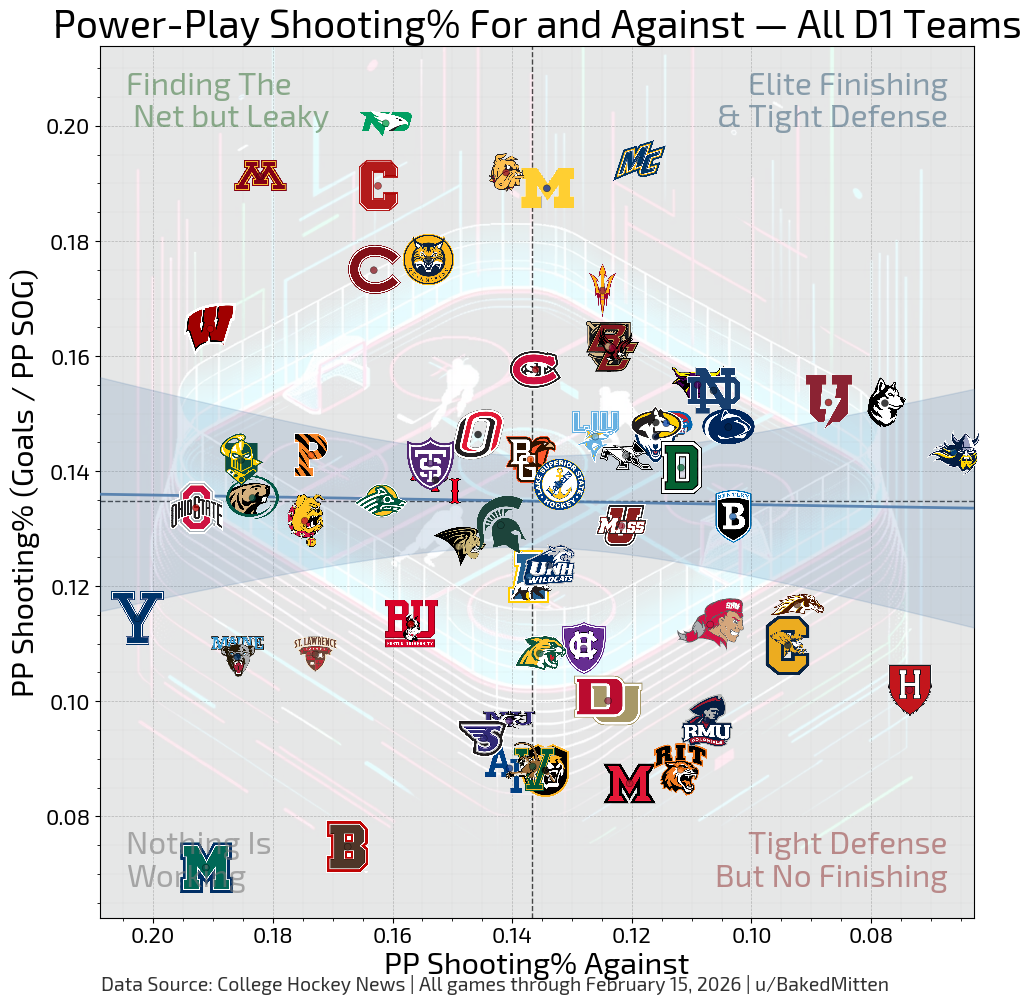

Done creating league scatterplot set.


In [105]:
# ###############################################################
# # CREATE LEAGUE-WIDE SCATTERPLOTS (one plot per metric)
# ###############################################################

league_plot_folder = os.path.join(plot_folder, "League")
os.makedirs(league_plot_folder, exist_ok=True)

print("Creating league-wide scatterplots...")

for metric_key in PLOT_CONFIGS.keys():

    title = f"{PLOT_CONFIGS[metric_key]['title']} — All D1 Teams"

    output_path = os.path.join(
        league_plot_folder,
        f"D1_{metric_key}_{config.last_game_date}.png"
    )

    print(f"Creating: {metric_key}")

    create_metric_scatter(
        metric_key=metric_key,
        config_dict=PLOT_CONFIGS,
        dataframes=DATAFRAMES,
        highlight_teams=ALL_D1_TEAMS,   # show logos for everyone
        logo_mapping=logo_mapping,
        logo_folder=logo_folder,
        team_color_mapping=team_color_mapping,
        title=title,
        output_path=output_path,
        plot_folder=league_plot_folder,
        bg_img=bg_img,
        alpha_value=alpha_value,
        footer_text=f"Data Source: College Hockey News | All games through {config.last_game_date} | u/BakedMitten",
        font_title_param=font_title_param,
        font_label_param=font_label_param,
    )

print("Done creating league scatterplot set.")


In [106]:
team_53_summary.columns

Index(['Team', 'Opps_53_For', 'Goals_53_For', 'Time_53_For_sec', 'Opps_Scored',
       'Opps_GF2plus', 'Opps_53_Against', 'Goals_53_Allowed',
       'Time_53_Against_sec', 'Opps_Allowed', 'SHG_for_while_3v5',
       'ConvRate_anyGoal', 'GF_per_53', 'GF60_53', 'Survival_53', 'GA_per_53',
       'GA60_53', 'Net_GF_53', 'Net_Min_UpMinusDown'],
      dtype='object')

In [107]:
DATAFRAMES.keys()
team_53_summary["Net_Min_UpMinusDown"] = (team_53_summary["Time_53_For_sec"] - team_53_summary["Time_53_Against_sec"]) / 60.0


In [108]:
# create_metric_scatter(
#     metric_key="extreme_53_net_minutes_vs_gd",
#     config_dict=PLOT_CONFIGS,
#     dataframes=DATAFRAMES,
#     highlight_teams=ALL_D1_TEAMS,   # show logos for everyone
#     logo_mapping=logo_mapping,
#     logo_folder=logo_folder,
#     team_color_mapping=team_color_mapping,
#     # title=f"5on3 Minute and Goal Differential — All D1 Teams",
#     output_path=os.path.join(plot_folder, "League", f"D1_extreme_53_net_minutes_vs_gd_{config.last_game_date}.png"),
#     plot_folder=os.path.join(plot_folder, "League"),
#     bg_img=bg_img,
# )

In [109]:
# create_metric_scatter(
#     metric_key="extreme_53_exposure",
#     config_dict=PLOT_CONFIGS,
#     dataframes=DATAFRAMES,
#     highlight_teams=DATAFRAMES["team_53_summary"]["Team"].tolist(),  # show logos for teams with 5+3 data
#     logo_mapping=logo_mapping,
#     logo_folder=logo_folder,
#     team_color_mapping=team_color_mapping,  # optional, dots underneath
#     bg_img=bg_img,                          # optional rink bg
# )


In [110]:
# ############# CREATE PLOTS FOR ALL CONFERENCES AND METRICS #############
# #### Call a loop to create all conference plots for all metrics
# from config import conference_teams, team_color_mapping

# # Build this ONCE and pass it into every call
# DATAFRAMES = {
#     "merged_df": merged_df,
#     "shooting_pct_df": shooting_pct_df,
#     "penalty_compare_df": penalty_compare_df,
# }

# for metric_key in PLOT_CONFIGS.keys():
#     for conf_key, team_list in conference_teams.items():

#         title = f"{PLOT_CONFIGS[metric_key]['title']}: {conf_key}"
#         output_path = os.path.join(
#             plot_folder,
#             f"{conf_key.replace(' ', '_')}_{metric_key}_{config.last_game_date}.png"
#         )

#         create_metric_scatter(
#             metric_key=metric_key,
#             config_dict=PLOT_CONFIGS,
#             dataframes=DATAFRAMES,
#             highlight_teams=team_list,
#             logo_mapping=logo_mapping,
#             logo_folder=logo_folder,
#             team_color_mapping=team_color_mapping,   # <-- colors for all dots
#             title=title,
#             output_path=output_path,
#             plot_folder=plot_folder,
#             bg_img=bg_img,
#             alpha_value=alpha_value,
#             footer_text=f"Includes all games through {config.last_game_date}. Data Source: College Hockey News",
#             font_title_param=font_title_param,
#             font_label_param=font_label_param,
#         )
